**Recipe recommendation with two towers: sentiment with negative sampling**

Ratings come from `input_stage2/recipe_user_ratings.csv` (run `map_recipe_nutrients.ipynb` first when rebuilding it: each
rating keeps its original **date**); minutes, steps, descriptions and tags come from `input/RecipeInteraction/RAW_recipes.csv`.
The data is prepared the way `model_training_mf_als.ipynb` prepares it:

```text
ratings 0–2★ and 4–5★ (0 = a review without stars; 3★ ratings are removed when the data is loaded)
    → the latest rating per (user, recipe); users with ≥ 6 of these ratings (no recipe minimum)
    → split per user by date: the latest rating is test, the one before valid, the rest train
    → sentiment: positive (4–5★) or negative (0–2★), one-hot as sentiment_positive / sentiment_negative
    → negative sampling: 1 unobserved recipe per positive, added with rating 0 (negative), in the positive's split
    → item tower: one projection per feature group (nutrition, price, time, text, ingredients, adjectives,
                  verbs, tags, recipe ID) → concat → MLP → L2-normalize
    → user tower: the item tower on the user's earlier ratings, each with its sentiment one-hot → mean of the
                  positive ones (recency-weighted) + a GRU over the whole history → MLP → L2-normalize
    → score: P(positive) = sigmoid(scale × cosine(user, recipe) + bias); loss: class-weighted focal loss
    → evaluate: precision / recall / F1 per sentiment, ROC AUC, confusion matrix on valid and test
    → recommend: the unseen recipes with the highest P(positive)
```

Every 5★ rating is used.

**Item tower.** Every feature group gets its own projection to `PART_DIM` (32) before the concat, so no group swamps the
others. Ingredients (products), adjectives and verbs are normalized, lowercased, lemmatized and singularized with the rules of
`model_training_mf_als.ipynb`; each distinct term gets a frozen all-MiniLM-L6-v2 vector, and a recipe's field is the mean of
its terms' vectors followed by a learned linear layer. The term vectors, the frozen BERT embedding of name + description and
the nutrients are **standardized and reduced by UMAP**; price and time are standardized. The recipe ID has its own embedding
with ID dropout (0.3), so the content groups carry the rarely rated recipes.

**User tower.** No user-ID embedding: a user is described by the recipes they rated before, each with its **sentiment
one-hot**. The positive ones are pooled by a recency-weighted mean (half weight per 180 days), and a GRU reads the whole
history, negatives included. Both towers are **L2-normalized**, so their dot product is the cosine similarity.

`model_training_reranker.ipynb` was built on the previous retrieval two-tower (liked-only rows, in-batch softmax, saved to
`model_artifacts/two_tower/`); this notebook no longer trains or saves that model, so the reranker needs updating before it
can use this one. Not used: review text.


In [1]:
# Run once if these packages are missing, then restart the notebook kernel.
# %pip install torch transformers==5.17.0 sentence-transformers nltk numpy pandas scikit-learn joblib matplotlib
import json
import random
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch
from IPython.display import display

**Configuration**

Data (as in `model_training_mf_als.ipynb`): `SENTIMENT_RATINGS` are the only ratings loaded (0–2★ negative, 4–5★ positive,
from `SENTIMENT_POSITIVE_MIN`); users need `MIN_USER_RATINGS = 6` of them; `SENTIMENT_NEGATIVES_PER_POSITIVE = 1` unobserved
recipe is sampled per positive and added with rating 0.

Recipe features: `TERM_MODEL` (all-MiniLM-L6-v2, pinned to `TERM_REVISION`) embeds every cleaned ingredient, adjective, verb and
tag term once; `BERT_MODEL` embeds each recipe's name + description (`TEXT_MAX_LENGTH` tokens). Text, terms and nutrients are
standardized and reduced by UMAP (`TEXT_UMAP_COMPONENTS`, `TERM_UMAP_COMPONENTS`, `NUTRIENT_UMAP_COMPONENTS`, with
`UMAP_NEIGHBORS`, `UMAP_MIN_DIST`, `UMAP_SEED`). Nutrition, price and time are `log1p`, clipped at the `CLIP_QUANTILE = 0.995`
quantile and standardized. Each missing price contributes **±$2** (`MISSING_PRICE_ERROR_DOLLARS`) of uncertainty, never an
imputed cost.

Model: `EMBEDDING_DIM = 64`, `PART_DIM = 32` per feature group, `HIDDEN_DIM = 128`, `ITEM_ID_DROPOUT = 0.3`,
`MIN_ITEM_RATINGS_FOR_ID = 5`, `NORMALIZE_EMBEDDINGS = True`, `RECENCY_HALF_LIFE_DAYS = 180`, `MAX_HISTORY = 64`.
Training: class-weighted focal loss (`SENTIMENT_FOCAL_GAMMA`, `SENTIMENT_WEIGHT_BALANCE`), `SENTIMENT_EPOCHS`,
`SENTIMENT_BATCH_SIZE`, `SENTIMENT_LEARNING_RATE`, early stopping after `SENTIMENT_PATIENCE` epochs, at most
`SENTIMENT_MAX_ROWS_PER_USER` rows per user per epoch; `SENTIMENT_DECISION_THRESHOLD` turns P(positive) into a prediction.
`NUM_WORKERS` is 2 on Linux (Colab, Kaggle) and 0 on macOS and Windows, where DataLoader workers can't load classes defined in
a notebook.


In [2]:
RANDOM_STATE = 42
BERT_MODEL = "bert-base-uncased"  # Frozen encoder of each recipe's name + description.
BERT_REVISION = "86b5e0934494bd15c9632b12f734a8a67f723594"
TERM_MODEL = "sentence-transformers/all-MiniLM-L6-v2"  # Frozen vector per ingredient, adjective, verb, and tag.
TERM_REVISION = "1110a243fdf4706b3f48f1d95db1a4f5529b4d41"
TERM_BATCH_SIZE = 256
TEXT_MAX_LENGTH = 64  # Tokens of "name. description" (median description is 27 words).
TEXT_BATCH_SIZE = 128
CLIP_QUANTILE = 0.995  # Nutrition, price, and time: log1p, clip at this quantile, standardize.
MISSING_PRICE_ERROR_DOLLARS = 2.0
RECENCY_HALF_LIFE_DAYS = 180.0
MAX_HISTORY = 64
EMBEDDING_DIM = 64
PART_DIM = 32  # Every item feature group is projected to this size before the concat.
HIDDEN_DIM = 128
ITEM_ID_DROPOUT = 0.3  # Share of training rows whose recipe ID is hidden, so the content groups carry weight.
MIN_ITEM_RATINGS_FOR_ID = 5  # Recipes with fewer positive train rows share the zero PAD row and rely on content alone.
NORMALIZE_EMBEDDINGS = True  # L2-normalized towers: the dot product is the cosine similarity.
# DataLoader workers need fork (Linux: Colab, Kaggle); macOS and Windows can't load notebook classes in them.
NUM_WORKERS = 2 if sys.platform.startswith("linux") else 0

# Data, as in model_training_mf_als.ipynb.
SENTIMENT_RATINGS = (0, 1, 2, 4, 5)  # The only ratings loaded: 0-2 stars negative sentiment, 4-5 positive.
SENTIMENT_POSITIVE_MIN = 4  # 4-5 stars: positive sentiment.
MIN_USER_RATINGS = 6  # Users need this many of those ratings.
SENTIMENT_NEGATIVES_PER_POSITIVE = 1  # Unobserved recipes per positive, added with rating 0 (1 : 1).
# Recipe features: standardize -> UMAP -> standardize.
TEXT_UMAP_COMPONENTS = 32  # BERT name + description (768-d).
TERM_UMAP_COMPONENTS = 32  # MiniLM term vectors (384-d).
NUTRIENT_UMAP_COMPONENTS = 6  # Nutrients (7), after log1p and the clip.
UMAP_NEIGHBORS, UMAP_MIN_DIST = 15, 0.0
UMAP_SEED = RANDOM_STATE  # Reproducible but single-threaded; None uses every core (faster, not reproducible).
# Training.
SENTIMENT_FOCAL_GAMMA = 2.0  # (1 - p_t)^gamma, as in model_training_mf_als.ipynb; 0 = class-weighted BCE.
SENTIMENT_WEIGHT_BALANCE = 1.0  # Class weight (n / (2 n_c)) ** beta: 1 = balanced, 0 = unweighted.
SENTIMENT_DECISION_THRESHOLD = 0.5  # P(positive) >= this is predicted positive.
SENTIMENT_EPOCHS = 10
SENTIMENT_BATCH_SIZE = 1024
SENTIMENT_LEARNING_RATE = 1e-3
SENTIMENT_PATIENCE = 3  # Epochs without a better valid weighted log loss before stopping.
SENTIMENT_MAX_ROWS_PER_USER = 100  # Per-epoch cap on a user's training rows, resampled every epoch.

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
# CUDA first, then Apple-silicon MPS, then CPU.
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif device.type == "mps":
    print("GPU: Apple silicon (MPS)")
else:
    import warnings
    warnings.warn(f"No GPU visible (torch {torch.__version__}, built for CUDA {torch.version.cuda}); training on "
                  "the CPU. On Colab: Runtime > Change runtime type > GPU. On Kaggle: Settings > Accelerator > "
                  "GPU. If CUDA is None there, a CPU-only torch was installed.", stacklevel=1)
NOTEBOOK_DIR = next((p for p in (Path.cwd(), Path.cwd() / "DataMappingRecommendation")
                     if (p / "input_stage2/recipe_user_ratings.csv").is_file()), None)
if NOTEBOOK_DIR is None:
    raise FileNotFoundError("Run from DataMappingRecommendation or its project root; restore recipe_user_ratings.csv.")
DATA_PATH = NOTEBOOK_DIR / "input_stage2/recipe_user_ratings.csv"
RAW_RECIPES_PATH = NOTEBOOK_DIR / "input/RecipeInteraction/RAW_recipes.csv"  # minutes, n_steps, description, tags
SENTIMENT_ARTIFACT_DIR = NOTEBOOK_DIR / "model_artifacts/two_tower_sentiment"
CACHE_DIR = NOTEBOOK_DIR / "output/two_tower_cache"
print(f"Device: {device}; recipe data: {DATA_PATH}")

GPU: Apple silicon (MPS)
Device: mps; recipe data: /Users/tung/Desktop/Học/Projects/ProjectSem1_2/DataMappingRecommendation/input_stage2/recipe_user_ratings.csv


**Self-contained model and data definitions**

The next three cells hold every definition: the two towers and their history handling (tagged `two-tower-core`), the recipe
content features (`two-tower-features`), and the sentiment data, training, evaluation and recommendation. The core cell also
keeps the in-batch-softmax helpers of the previous retrieval model, which `model_training_reranker.ipynb` and the tests still
use; this notebook does not train with them. No local model module is required.


In [3]:
"""Two-tower model following two-tower-embeddings.md: a shared item tower, and a user tower that pools the item-tower
vectors of the recipes the user liked. This notebook trains it on sentiment labels (the sentiment definitions cell); the
in-batch-softmax training helpers below belong to the previous retrieval model and are kept for the reranker and tests."""
import copy
import math
import sys
import warnings
from decimal import Decimal, InvalidOperation

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset, default_collate

NUM_RATING_CLASSES = 5  # Rating slots 1..5 -> classes 0..4 (history tokens, the reranker's labels); only 1, 2, 4, 5 occur.
USED_RATINGS = (1, 2, 4, 5)  # Every other rating (0, a review without stars, and 3) is cut when the ratings are loaded.
POSITIVE_MIN_RATING = 4  # Ratings 4-5 are positives (the user liked the recipe); 1-2 are negatives.
LEVEL_NAMES = ("negative", "positive")  # 1-2 stars, and 4-5 stars.
NEGATIVE, POSITIVE = range(len(LEVEL_NAMES))
RATING_CLASS_LEVELS = np.array([POSITIVE if rating >= POSITIVE_MIN_RATING else NEGATIVE for rating in range(1, 6)])
# Weight of a history recipe in the user's pooled vector, by rating 1..5: liked recipes only, 5 stars most.
POOL_RATING_WEIGHTS = tuple(float(max(0, rating - POSITIVE_MIN_RATING + 1)) for rating in range(1, 6))
# Roles of the cells in a [B, B] logits grid; ROLE_LIKED cells are masked to -inf.
BATCH_ROLES = ("N", "P", "mask: liked")
ROLE_N, ROLE_P, ROLE_LIKED = range(len(BATCH_ROLES))


def canonical_id(value):
    """Normalize integer IDs loaded as numbers, strings, or CSV float strings."""
    if value is None or pd.isna(value):
        return None
    value = str(value).strip()
    if value.lower() in {"", "nan", "none", "null", "<na>"}:
        return None
    try:
        number = Decimal(value)
        if not number.is_finite():
            return None
        if number == number.to_integral_value():
            return str(int(number))
    except InvalidOperation:
        pass
    return value


def build_interactions(df, catalog):
    """One row per (user, recipe): the latest rating in USED_RATINGS (1-2 or 4-5 stars), with its date and level.

    Every other row is cut before the latest rating is picked: no rating, rating 0 (a review without stars), and 3 stars.
    """
    required = {"recipe_id", "user_id", "rating", "date"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Missing interaction columns {sorted(missing)}. Rerun map_recipe_nutrients.ipynb to export the original rating date.")
    catalog_ids = catalog["recipe_id"].map(canonical_id)
    if catalog_ids.isna().any() or catalog_ids.duplicated().any():
        raise ValueError("Catalog recipe_id values must be valid and unique after ID normalization.")
    frame = df.loc[:, ["recipe_id", "user_id", "rating", "date"]].copy()
    ratings = pd.to_numeric(frame["rating"], errors="coerce")
    malformed = frame["rating"].notna() & ratings.isna()
    invalid = ratings.notna() & ratings.ne(0) & ~ratings.between(1, 5)
    if malformed.any() or invalid.any():
        raise ValueError("Ratings must be numeric values from 1 to 5; use 0 or null for unlabeled rows.")
    frame["rating"] = ratings
    frame = frame.loc[ratings.isin(USED_RATINGS)].copy()
    frame["user_id"] = frame["user_id"].map(canonical_id)
    frame["recipe_id"] = frame["recipe_id"].map(canonical_id)
    valid_ids = frame["user_id"].notna() & frame["recipe_id"].isin(set(catalog_ids))
    if (~valid_ids).any():
        warnings.warn(f"Excluded {(~valid_ids).sum():,} labeled rows with missing user IDs or recipes absent from the catalog.", stacklevel=2)
    frame = frame.loc[valid_ids].copy()
    frame["date"] = pd.to_datetime(frame["date"], format="mixed", errors="coerce", utc=True)
    if frame["date"].isna().any():
        raise ValueError("Labeled interactions contain missing/invalid dates. Rerun map_recipe_nutrients.ipynb and regenerate the mapped CSV with original dates; do not invent timestamps.")
    item_lookup = dict(zip(catalog_ids, range(len(catalog_ids))))
    frame["item_index"] = frame["recipe_id"].map(item_lookup).astype("int64")
    frame = frame.sort_values("date", kind="stable").drop_duplicates(["user_id", "recipe_id"], keep="last")
    frame["level"] = np.asarray(LEVEL_NAMES)[rating_to_level(frame["rating"])]
    return frame[["user_id", "item_index", "rating", "level", "date"]].reset_index(drop=True)


def core_filter(interactions, min_user_ratings=3, min_recipe_ratings=5):
    """Drop users with fewer than min_user_ratings ratings and recipes with fewer than
    min_recipe_ratings, repeatedly, until every remaining user and recipe has enough."""
    if min_user_ratings < 1 or min_recipe_ratings < 1:
        raise ValueError("The minimum rating counts must be positive.")
    frame = interactions
    while True:
        users = frame["user_id"].map(frame["user_id"].value_counts())
        items = frame["item_index"].map(frame["item_index"].value_counts())
        kept = frame.loc[users.ge(min_user_ratings) & items.ge(min_recipe_ratings)]
        if len(kept) == len(frame):
            return kept.reset_index(drop=True)
        frame = kept


def per_user_split(interactions, holdout_per_user=2):
    """Hold out each user's last holdout_per_user ratings by date; the rest train.

    A user needs more ratings than that to be held out at all, so every held-out user keeps
    training rows. Same-day ties keep their input order.
    """
    if holdout_per_user < 1:
        raise ValueError("holdout_per_user must be positive.")
    frame = interactions.sort_values(["user_id", "date"], kind="stable").reset_index(drop=True)
    from_end = frame.groupby("user_id", sort=False).cumcount(ascending=False)
    sizes = frame["user_id"].map(frame["user_id"].value_counts())
    heldout = (from_end < holdout_per_user) & (sizes > holdout_per_user)
    return frame.loc[~heldout].reset_index(drop=True), frame.loc[heldout].reset_index(drop=True)


def rating_classes(ratings):
    """Map integer ratings 1..5 to ordinal class indices 0..4."""
    values = np.asarray(ratings, dtype=np.float64)
    classes = np.rint(values) - 1
    if not np.isin(classes, np.arange(NUM_RATING_CLASSES)).all() or not np.array_equal(values, classes + 1):
        raise ValueError("Rating classes require integer ratings from 1 to 5.")
    return classes.astype(np.int64)


def rating_to_level(ratings):
    """Level index per rating: negative (1-2) or positive (4-5)."""
    return RATING_CLASS_LEVELS[rating_classes(ratings)]


def positive_rows(frame):
    """Training rows: ratings of POSITIVE_MIN_RATING (4) or more. 1-2 star ratings stay in histories only."""
    return frame.loc[rating_to_level(frame["rating"]) == POSITIVE].reset_index(drop=True)


def _isin_sorted(values, sorted_keys):
    """Elementwise membership of integer values in a sorted, unique integer array."""
    values = np.asarray(values)
    if not len(sorted_keys):
        return np.zeros(values.shape, dtype=bool)
    positions = np.searchsorted(sorted_keys, values).clip(max=len(sorted_keys) - 1)
    return sorted_keys[positions] == values


def build_item_id_rows(positive_items, num_items, min_ratings=5):
    """Recipe-ID embedding row for every catalog recipe, and how many recipes get their own row.

    Recipes with at least min_ratings training positives get rows 1..n; all others share
    row 0, the zero PAD row, and rely on their content features alone.
    """
    if min_ratings < 1:
        raise ValueError("min_ratings must be positive.")
    counts = np.bincount(np.asarray(positive_items, dtype=np.int64), minlength=num_items)[:num_items]
    kept = np.flatnonzero(counts >= min_ratings)
    rows = np.zeros(num_items, dtype=np.int64)
    rows[kept] = np.arange(1, len(kept) + 1)
    return rows, len(kept)


class HistoryIndex:
    """Each user's ratings sorted by date: (dates in ns, item indices, rating classes 0..4)."""
    def __init__(self, history):
        frame = history.sort_values("date", kind="stable")
        dates = frame["date"].astype("int64").to_numpy()
        items = frame["item_index"].to_numpy(dtype=np.int64)
        classes = rating_classes(frame["rating"])
        self.users = {canonical_id(user): (dates[positions], items[positions], classes[positions])
                      for user, positions in frame.groupby("user_id", sort=False).indices.items()}


def _utc_day(value):
    stamp = pd.Timestamp(value)
    if pd.isna(stamp):
        raise ValueError("A valid as_of/reference_date is required.")
    return (stamp.tz_localize("UTC") if stamp.tzinfo is None else stamp.tz_convert("UTC")).floor("D")


def user_history(index, user_id, as_of, max_history=64, exclude_item=None):
    """Up to max_history ratings from UTC days strictly before as_of, oldest first.

    Returns item indices, rating classes 0..4, and each rating's age in days at as_of's day.
    exclude_item (one recipe index or several) is left out, e.g. the target recipe.
    """
    if max_history < 1:
        raise ValueError("max_history must be positive.")
    cutoff = int(as_of) if isinstance(as_of, (int, np.integer)) else _utc_day(as_of).value
    records = index.users.get(canonical_id(user_id))
    if records is None:
        return np.empty(0, np.int64), np.empty(0, np.int64), np.empty(0, np.float32)
    dates, items, classes = records
    end = np.searchsorted(dates, cutoff, side="left")
    excluded = np.atleast_1d(np.asarray([] if exclude_item is None else exclude_item, dtype=np.int64))
    # A user rates each recipe once, so one spare row per excluded recipe keeps max_history rows.
    selected = np.arange(max(0, end - max_history - len(excluded)), end)
    selected = selected[~np.isin(items[selected], excluded)][-max_history:]
    age_days = ((cutoff - dates[selected]) / (86400 * 1e9)).astype(np.float32)
    return items[selected], classes[selected], age_days


def pad_history(items, classes, age_days, max_history=64):
    """Right-pad one history to max_history steps; history_mask marks real ratings."""
    padded = {"history_items": np.zeros(max_history, np.int64), "history_ratings": np.zeros(max_history, np.int64),
              "history_age_days": np.zeros(max_history, np.float32), "history_mask": np.zeros(max_history, bool)}
    length = len(items)
    for key, values in [("history_items", items), ("history_ratings", classes), ("history_age_days", age_days)]:
        padded[key][:length] = values
    padded["history_mask"][:length] = True
    return {key: torch.from_numpy(value) for key, value in padded.items()}


def build_user_lookup(history):
    """Vocabulary of training users, 1..n. The model has no user-ID embedding; the reranker uses it."""
    users = sorted(history["user_id"].map(canonical_id).dropna().unique())
    return {user: index for index, user in enumerate(users, start=1)}


def _feature_tensor(item_features, device):
    """Item features on the compute device, copied once so per-batch gathers stay there."""
    if torch.is_tensor(item_features):
        return item_features.to(device=device, dtype=torch.float32)
    return torch.as_tensor(np.asarray(item_features, dtype=np.float32)).to(device)


def user_inputs(batch, features, device):
    """User-tower tensors for one batch, trimmed to its longest history: the history recipes'
    indices and dense features (the shared item tower encodes them), ratings, ages, and mask."""
    width = max(1, int(batch["history_mask"].sum(dim=1).max()))
    history_items = batch["history_items"][:, :width]
    return (history_items.to(device), features[history_items.to(features.device)].to(device),
            batch["history_ratings"][:, :width].to(device), batch["history_age_days"][:, :width].to(device),
            batch["history_mask"][:, :width].to(device))


class HistoryDataset(Dataset):
    """One row per positive target, with the user's strictly earlier ratings as a dated sequence.

    collate() batches rows with the [B, B] mask of the in-batch softmax: a column holding another
    recipe the row's user liked (4-5 stars, in the history, the targets, or extra_interactions,
    e.g. the held-out ratings for validation) is masked, since it isn't a real negative.
    resample() picks each epoch's rows (at most max_per_user per user).
    """
    def __init__(self, targets, history, max_history=64, half_life_days=180, training=True,
                 reference_date=None, weight_floor=0.1, extra_interactions=None):
        self.targets = targets.reset_index(drop=True).copy()
        self.history_index = HistoryIndex(history)
        self.max_history, self.half_life_days = max_history, half_life_days
        if max_history < 1 or half_life_days <= 0 or not 0 < weight_floor <= 1:
            raise ValueError("Use max_history >= 1, half_life_days > 0, and 0 < weight_floor <= 1.")
        rating_classes(self.targets["rating"])  # Validates the target ratings.
        self.cutoffs = self.targets["date"].dt.floor("D").astype("int64").to_numpy()
        self.weights = np.ones(len(self.targets), dtype=np.float32)
        if training and len(self.targets):
            reference = history["date"].max() if reference_date is None else reference_date
            reference = _utc_day(reference)
            age = (reference - self.targets["date"].dt.floor("D")).dt.total_seconds().to_numpy() / 86400
            self.weights = np.maximum(weight_floor, np.exp2(-np.maximum(age, 0) / half_life_days)).astype(np.float32)
        self.active = np.arange(len(self.targets))  # This epoch's rows; see resample().
        # The mask's (user, recipe) keys are built on first use from every rating this dataset sees.
        self._mask_frames = [frame for frame in (history, extra_interactions) if frame is not None] + [self.targets]
        self._mask_sets = None

    @property
    def mask_sets(self):
        """Sorted (user, recipe) keys of every liked (4-5 star) rating in the history, extras, and targets."""
        if self._mask_sets is None:
            ratings = pd.concat([frame[["user_id", "item_index", "rating"]] for frame in self._mask_frames],
                                ignore_index=True)
            codes, users = pd.factorize(ratings["user_id"])
            stride = int(ratings["item_index"].max()) + 1 if len(ratings) else 1
            keys = codes.astype(np.int64) * stride + ratings["item_index"].to_numpy(dtype=np.int64)
            liked = rating_to_level(ratings["rating"]) == POSITIVE
            self._mask_sets = {"stride": stride,
                               "row_codes": pd.Index(users).get_indexer(self.targets["user_id"]).astype(np.int64),
                               "positive_keys": np.unique(keys[liked])}
        return self._mask_sets

    def resample(self, max_per_user=None, seed=None):
        """Choose this epoch's rows: all of them, or at most max_per_user random rows per user."""
        if max_per_user is None:
            self.active = np.arange(len(self.targets))
            return self
        if max_per_user < 1:
            raise ValueError("max_per_user must be positive.")
        order = np.random.default_rng(seed).permutation(len(self.targets))
        users = self.targets["user_id"].to_numpy()[order]
        rank = pd.Series(users).groupby(users, sort=False).cumcount().to_numpy()
        self.active = np.sort(order[rank < max_per_user])
        return self

    def batch_roles(self, rows, positives):
        """Role of every cell in the [B, B] logits grid, as codes into BATCH_ROLES.

        Column j holds row j's positive recipe. Row i's own positive is the diagonal (P). A column
        holding another recipe row i's user liked is masked; every other cell, including a recipe
        the user rated 1-2 stars, is an in-batch negative (N).
        """
        sets = self.mask_sets
        positives = np.asarray(positives, dtype=np.int64)
        size = len(positives)
        keys = sets["row_codes"][np.asarray(rows, dtype=np.int64)][:, None] * sets["stride"] + positives[None, :]
        roles = np.full((size, size), ROLE_N, dtype=np.int8)
        roles[_isin_sorted(keys, sets["positive_keys"])] = ROLE_LIKED
        roles[np.arange(size), np.arange(size)] = ROLE_P
        return roles

    def collate(self, samples):
        """Default batching, plus the [B, B] in-batch softmax mask."""
        batch = default_collate(samples)
        roles = self.batch_roles(batch["row"].numpy(), batch["item_index"].numpy())
        batch["mask"] = torch.from_numpy(roles == ROLE_LIKED)
        return batch

    def __len__(self):
        return len(self.active)

    def __getitem__(self, index):
        position = int(self.active[index])
        row = self.targets.iloc[position]
        # Serving candidates are unrated, so the target recipe is never read from the history.
        sample = pad_history(*user_history(self.history_index, row.user_id, int(self.cutoffs[position]),
                                           self.max_history, exclude_item=row.item_index), self.max_history)
        sample.update({"item_index": int(row.item_index), "rating": torch.tensor(row.rating, dtype=torch.float32),
                       "sample_weight": torch.tensor(self.weights[position], dtype=torch.float32),
                       "row": position})
        return sample


def history_pool_weights(history_ratings, history_age_days, history_mask, half_life_days,
                         rating_weights=POOL_RATING_WEIGHTS):
    """Weight of each history recipe in the user's pooled vector (two-tower-embeddings.md: a
    rating-weighted mean): its rating's weight (0 for 1-2 stars) x 2^(-age / half-life), normalized
    over the liked recipes. A history without liked recipes gets all-zero weights."""
    rating_log_weights = torch.as_tensor(rating_weights, dtype=history_age_days.dtype,
                                         device=history_age_days.device).log()
    log_weights = rating_log_weights[history_ratings] - history_age_days * (math.log(2) / half_life_days)
    log_weights = log_weights.masked_fill(~history_mask, float("-inf"))
    liked = torch.isfinite(log_weights).any(dim=-1, keepdim=True)
    return torch.softmax(log_weights.masked_fill(~liked, 0.0), dim=-1) * liked


class TwoTowerModel(nn.Module):
    """Two towers that share the item tower (two-tower-embeddings.md); the score is their dot product.

    Item tower: each feature group has its own projection to part_dim, so no group swamps the
    others. Dense groups (column ranges of the item feature matrix: nutrition, price, time,
    text) each get a linear layer; each term field (ingredients, adjectives, verbs) is the mean
    of its terms' frozen pretrained vectors followed by a learned linear layer; and the recipe
    ID has an embedding with ID dropout in training. Concat -> MLP -> L2-normalize.

    User tower: the item-tower vectors of the user's history recipes; a rating x recency weighted
    mean of the liked (4-5 star) ones, concatenated with a GRU's summary of the whole rating
    sequence (oldest first) -> MLP -> L2-normalize. There is no user-ID embedding.
    """
    def __init__(self, feature_groups, num_items, embedding_dim=64, part_dim=32, hidden_dim=128, rating_dim=16,
                 half_life_days=180.0, num_item_ids=0, item_id_dropout=0.3, num_terms=0, term_dim=0,
                 term_fields=(), pool_rating_weights=POOL_RATING_WEIGHTS, normalize=True):
        super().__init__()
        feature_groups = [[str(name), int(start), int(end)] for name, start, end in feature_groups]
        term_fields = [[str(field), int(width)] for field, width in term_fields]
        if num_items < 1 or half_life_days <= 0 or not 0 <= item_id_dropout < 1:
            raise ValueError("Use num_items >= 1, half_life_days > 0, and item_id_dropout in [0, 1).")
        if any(end <= start for _, start, end in feature_groups):
            raise ValueError("Each feature group needs at least one column.")
        if term_fields and (num_terms < 1 or term_dim < 1):
            raise ValueError("Term fields need num_terms and term_dim.")
        if len(pool_rating_weights) != NUM_RATING_CLASSES or min(pool_rating_weights) < 0:
            raise ValueError("pool_rating_weights needs one nonnegative weight per rating 1..5.")
        self.config = {"feature_groups": feature_groups, "num_items": int(num_items),
                       "embedding_dim": embedding_dim, "part_dim": part_dim, "hidden_dim": hidden_dim,
                       "rating_dim": rating_dim, "half_life_days": float(half_life_days),
                       "num_item_ids": int(num_item_ids), "item_id_dropout": float(item_id_dropout),
                       "num_terms": int(num_terms) if term_fields else 0, "term_dim": int(term_dim) if term_fields else 0,
                       "term_fields": term_fields, "pool_rating_weights": [float(w) for w in pool_rating_weights],
                       "normalize": bool(normalize)}
        # Item tower: one projection per feature group.
        self.group_projections = nn.ModuleDict({name: nn.Linear(end - start, part_dim)
                                                for name, start, end in feature_groups})
        # Frozen pretrained term vectors (row 0 pads); a recipe's bag is the mean of its terms' vectors.
        self.term_bag = (nn.EmbeddingBag(num_terms + 1, term_dim, mode="mean", padding_idx=0)
                         if term_fields else None)
        if self.term_bag is not None:
            self.term_bag.weight.requires_grad_(False)
        self.term_projections = nn.ModuleDict({field: nn.Linear(term_dim, part_dim) for field, _ in term_fields})
        for field, width in term_fields:
            self.register_buffer(f"{field}_ids", torch.zeros(num_items, max(1, width), dtype=torch.int32))
        # Row 0 is the zero PAD row: recipes with too few ratings rely on their content alone.
        self.item_embedding = nn.Embedding(num_item_ids + 1, part_dim, padding_idx=0) if num_item_ids > 0 else None
        if self.item_embedding is not None:
            self.register_buffer("item_id_rows", torch.zeros(num_items, dtype=torch.long))
        parts = len(feature_groups) + len(term_fields) + (self.item_embedding is not None)
        self.item_mlp = nn.Sequential(nn.Linear(parts * part_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
                                      nn.Linear(hidden_dim, embedding_dim))
        # User tower: pooled liked history + GRU over the rating sequence.
        self.rating_embedding = nn.Embedding(NUM_RATING_CLASSES, rating_dim)
        self.history_rnn = nn.GRU(embedding_dim + rating_dim + len(LEVEL_NAMES) + 1, hidden_dim, batch_first=True)
        self.register_buffer("rating_level", torch.as_tensor(RATING_CLASS_LEVELS), persistent=False)
        self.user_mlp = nn.Sequential(nn.Linear(embedding_dim + hidden_dim + 3, hidden_dim), nn.LayerNorm(hidden_dim),
                                      nn.ReLU(), nn.Linear(hidden_dim, embedding_dim))

    def set_item_id_rows(self, rows):
        """Map catalog recipe index -> recipe-ID embedding row (see build_item_id_rows)."""
        if self.item_embedding is None:
            raise ValueError("This model has no recipe-ID embeddings.")
        rows = torch.as_tensor(np.asarray(rows), dtype=torch.long)
        if rows.shape != self.item_id_rows.shape or rows.min() < 0 or rows.max() > self.config["num_item_ids"]:
            raise ValueError("rows must map every catalog recipe to 0..num_item_ids.")
        self.item_id_rows.copy_(rows.to(self.item_id_rows.device))
        return self

    def set_term_vectors(self, vectors):
        """Load the frozen pretrained term vectors, [num_terms, term_dim]; term id t is row t + 1."""
        vectors = torch.as_tensor(np.asarray(vectors, dtype=np.float32))
        if self.term_bag is None or tuple(vectors.shape) != (self.config["num_terms"], self.config["term_dim"]):
            raise ValueError("vectors must be [num_terms, term_dim] for a model with term fields.")
        with torch.no_grad():
            self.term_bag.weight[0].zero_()
            self.term_bag.weight[1:].copy_(vectors.to(self.term_bag.weight.device))
        return self

    def set_item_terms(self, field, matrix):
        """One field's per-recipe term ids + 1, padded with 0 (see term_id_matrix)."""
        if field not in self.term_projections:
            raise ValueError(f"Unknown term field {field!r}.")
        buffer = getattr(self, f"{field}_ids")
        matrix = torch.as_tensor(np.asarray(matrix), dtype=torch.int32)
        if (matrix.shape != buffer.shape or matrix.min() < 0 or matrix.max() > self.config["num_terms"]):
            raise ValueError("matrix must be [num_items, width] with term ids in 0..num_terms.")
        buffer.copy_(matrix.to(buffer.device))
        return self

    def _output(self, vectors):
        return F.normalize(vectors, dim=-1) if self.config["normalize"] else vectors

    def encode_items(self, features, item_index):
        """Item vectors for recipes item_index (any shape) with their dense features [..., feature_dim]."""
        parts = [self.group_projections[name](features[..., start:end])
                 for name, start, end in self.config["feature_groups"]]
        for field, _ in self.config["term_fields"]:
            ids = getattr(self, f"{field}_ids")[item_index].long()
            bags = self.term_bag(ids.reshape(-1, ids.shape[-1])).reshape(*ids.shape[:-1], -1)
            parts.append(self.term_projections[field](bags))
        if self.item_embedding is not None:
            rows = self.item_id_rows[item_index]
            if self.training and self.config["item_id_dropout"] > 0:
                # Randomly hide the ID, so the content groups carry weight (and rare recipes train well).
                rows = rows.masked_fill(torch.rand(rows.shape, device=rows.device) < self.config["item_id_dropout"], 0)
            parts.append(self.item_embedding(rows))
        return self._output(self.item_mlp(torch.cat(parts, dim=-1)))

    def encode_users(self, history_items, history_features, history_ratings, history_age_days, history_mask):
        """User vectors from the history alone: pooled liked recipes plus a GRU over every rating."""
        vectors = self.encode_items(history_features, history_items)  # The shared item tower, [B, L, E].
        lengths = history_mask.sum(dim=1)
        has_history = (lengths > 0).unsqueeze(-1).to(vectors.dtype)
        weights = history_pool_weights(history_ratings, history_age_days, history_mask,
                                       self.config["half_life_days"], self.config["pool_rating_weights"])
        pooled = (weights.unsqueeze(-1) * vectors).sum(dim=1)
        levels = F.one_hot(self.rating_level[history_ratings], len(LEVEL_NAMES)).to(vectors.dtype)
        steps = torch.cat([vectors, self.rating_embedding(history_ratings), levels,
                           torch.log1p(history_age_days).unsqueeze(-1)], dim=-1)
        outputs, _ = self.history_rnn(steps)
        # Right padding comes after every real step, so the GRU state at length - 1 is the latest rating's.
        last = outputs[torch.arange(len(outputs), device=outputs.device), (lengths - 1).clamp_min(0)] * has_history
        summary = torch.cat([pooled, last, has_history, (weights.sum(dim=1, keepdim=True) > 0).to(vectors.dtype),
                             torch.log1p(lengths.to(vectors.dtype)).unsqueeze(-1)], dim=-1)
        return self._output(self.user_mlp(summary))

    def similarity(self, users, items):
        """Dot product of tower vectors (the cosine similarity when the towers are normalized)."""
        return (users * items).sum(dim=-1)

    def forward(self, history_items, history_features, history_ratings, history_age_days, history_mask,
                item_features, item_index):
        """Two-tower score of each (history, item) row; higher means a closer match."""
        users = self.encode_users(history_items, history_features, history_ratings, history_age_days, history_mask)
        return self.similarity(users, self.encode_items(item_features, item_index))


def batch_softmax_losses(users, items, batch, log_q, temperature=0.05):
    """In-batch softmax cross-entropy per row (two-tower-embeddings.md; two-tower-implementation.md, section 5).

    logits = U·Iᵀ / τ − log q: row i's label is column i, its own positive, and every other
    column is an in-batch negative. log q, each recipe's share of training rows, corrects for
    popular recipes showing up as negatives more often. Cells in batch["mask"] (another recipe
    the row's user liked; from HistoryDataset.collate) become -inf.
    """
    device = items.device
    positive_ids = batch["item_index"].to(device)
    logits = users @ items.T / temperature - log_q[positive_ids]
    if "mask" in batch:
        mask = batch["mask"].to(device)
    else:  # Without HistoryDataset.collate: mask the row's recipe where it repeats in the batch.
        mask = positive_ids.unsqueeze(1) == positive_ids.unsqueeze(0)
        mask &= ~torch.eye(len(items), dtype=torch.bool, device=device)
    logits = logits.masked_fill(mask, float("-inf"))
    return F.cross_entropy(logits, torch.arange(len(items), device=device), reduction="none")


@torch.no_grad()
def evaluate_two_tower(model, dataset, item_features, batch_size=512, device=None, log_q=None, temperature=0.05):
    """Mean in-batch softmax cross-entropy over one pass of the dataset."""
    device = torch.device(device) if device is not None else next(model.parameters()).device
    features = _feature_tensor(item_features, device)
    if log_q is None:
        log_q = torch.zeros(len(features), device=device)
    loss_total, rows = 0.0, 0
    # Rows are sorted by user; a fixed shuffle mixes users like training does, same every epoch.
    order = torch.randperm(len(dataset), generator=torch.Generator().manual_seed(0)).tolist()
    model.eval()
    for batch in DataLoader(dataset, batch_size=batch_size, sampler=order, collate_fn=getattr(dataset, "collate", None)):
        item_ids = batch["item_index"].to(device)
        users = model.encode_users(*user_inputs(batch, features, device))
        losses = batch_softmax_losses(users, model.encode_items(features[item_ids], item_ids), batch, log_q, temperature)
        loss_total, rows = loss_total + float(losses.sum()), rows + len(losses)
    return {"in_batch_cross_entropy": loss_total / rows if rows else float("nan"), "in_batch_rows": rows}


class RecallAtK:
    """Recall@K on held-out positives, the guide's retrieval metric (two-tower-implementation.md, section 7).

    Evaluated users have held-out positives and at least one training rating. Each is embedded
    from all their training ratings, as of the day after the last one. Recipes they rated in
    training, and recipes outside candidate_items, are never recommended. Recall@K = held-out
    positives found in the top K / all held-out positives of the evaluated users (micro average).
    """
    def __init__(self, history, heldout, num_items, ks=(20, 100, 200), max_history=64, sample_users=None,
                 seed=42, candidate_items=None):
        if not ks or min(ks) < 1:
            raise ValueError("ks must be positive.")
        self.ks, self.num_items = tuple(sorted(set(ks))), num_items
        # Recipes outside candidate_items (e.g. dropped by the core filter) are never recommended.
        self.excluded = (None if candidate_items is None
                         else np.flatnonzero(~np.asarray(candidate_items, dtype=bool)))
        index = HistoryIndex(history)
        heldout_items = heldout.groupby("user_id")["item_index"].apply(lambda items: items.to_numpy(np.int64))
        users = [user for user in heldout_items.index if canonical_id(user) in index.users]
        if sample_users is not None and len(users) > sample_users:
            users = sorted(np.random.default_rng(seed).choice(users, sample_users, replace=False).tolist())
        cutoff = (_utc_day(history["date"].max()) + pd.Timedelta(1, unit="D")).value if len(history) else 0
        padded = [pad_history(*user_history(index, user, cutoff, max_history), max_history) for user in users]
        keys = ("history_items", "history_ratings", "history_age_days", "history_mask")
        self.inputs = {key: torch.stack([sample[key] for sample in padded]) for key in keys} if padded else {}
        self.seen = [index.users[canonical_id(user)][1] for user in users]
        self.targets = [heldout_items[user] for user in users]
        self.users = users

    def _recall(self, scores_for, device, batch_users):
        """Micro Recall@K, given scores_for(start, end) -> [users, recipes] scores on device."""
        total = int(sum(len(targets) for targets in self.targets))
        hits = np.zeros(len(self.ks))
        top_k = min(self.ks[-1], self.num_items)
        for start in range(0, len(self.users), batch_users):
            end = min(start + batch_users, len(self.users))
            scores = scores_for(start, end)
            if self.excluded is not None and len(self.excluded):
                scores[:, torch.as_tensor(self.excluded, device=device)] = -torch.inf
            seen, targets = self.seen[start:end], self.targets[start:end]
            seen_rows = np.repeat(np.arange(end - start), [len(items) for items in seen])
            scores[torch.as_tensor(seen_rows, device=device),
                   torch.as_tensor(np.concatenate(seen), device=device)] = -torch.inf
            wanted = torch.zeros(scores.shape, dtype=torch.bool, device=device)
            target_rows = np.repeat(np.arange(end - start), [len(items) for items in targets])
            wanted[torch.as_tensor(target_rows, device=device),
                   torch.as_tensor(np.concatenate(targets), device=device)] = True
            found = wanted.gather(1, scores.topk(top_k, dim=1).indices).cpu().numpy()
            hits += [found[:, :k].sum() for k in self.ks]
        result = {f"recall@{k}": hit / total if total else float("nan") for k, hit in zip(self.ks, hits)}
        result.update(users=len(self.users), heldout_positives=total)
        return result

    @torch.no_grad()
    def evaluate(self, model, item_features, device=None, batch_users=256):
        """Recall@K of the two-tower model."""
        device = torch.device(device) if device is not None else next(model.parameters()).device
        model.eval()
        features = _feature_tensor(item_features, device)
        item_vectors = encode_catalog(model, features, device=device).to(device)

        def scores_for(start, end):
            batch = {key: value[start:end] for key, value in self.inputs.items()}
            return model.encode_users(*user_inputs(batch, features, device)) @ item_vectors.T

        return self._recall(scores_for, device, batch_users)

    def popularity(self, item_scores, device="cpu", batch_users=256):
        """Recall@K of always recommending the highest item_scores, e.g. the most-liked recipes."""
        base = torch.as_tensor(np.asarray(item_scores, dtype=np.float32), device=device)
        return self._recall(lambda start, end: base.expand(end - start, -1).clone(), device, batch_users)


def train_two_tower(model, train_dataset, validation_dataset, item_features, epochs=20, batch_size=512,
                    learning_rate=1e-3, device=None, patience=4, in_batch_temperature=0.05,
                    max_rows_per_user=None, num_workers=0, recall_evaluator=None, seed=42):
    """Train with the in-batch softmax; keep the epoch with the lowest validation loss.

    Both datasets hold positive rows only (see positive_rows). Every epoch resamples at most
    max_rows_per_user rows per user. Recency sample weights scale each row's training loss;
    validation is unweighted. With a RecallAtK evaluator, Recall@K is also measured after
    every epoch. The frozen term vectors never train.
    """
    if not len(train_dataset.targets) or epochs < 1:
        raise ValueError("Training requires at least one labeled interaction and one epoch.")
    if in_batch_temperature <= 0:
        raise ValueError("Use a positive in_batch_temperature.")
    device = torch.device(device or ("cuda" if torch.cuda.is_available() else
                                     "mps" if torch.backends.mps.is_available() else "cpu"))
    torch.manual_seed(seed)
    model.to(device)
    features = _feature_tensor(item_features, device)
    # A recipe's (add-one smoothed) share of training rows is its in-batch sampling rate q.
    counts = np.bincount(train_dataset.targets["item_index"].to_numpy(dtype=np.int64), minlength=len(features))
    log_q = torch.as_tensor(np.log((counts + 1) / (counts.sum() + len(counts))), dtype=torch.float32, device=device)
    # Build the mask keys once, before any DataLoader worker is forked.
    train_dataset.mask_sets, validation_dataset.mask_sets
    optimizer = torch.optim.AdamW([parameter for parameter in model.parameters() if parameter.requires_grad],
                                  lr=learning_rate, weight_decay=1e-4)
    chance = math.log(batch_size)  # Relative loss: CE / ln B, the loss of scoring all B columns alike.
    best_score, best_state, best_metrics, stale, records = float("inf"), None, None, 0, []
    for epoch in range(1, epochs + 1):
        train_dataset.resample(max_rows_per_user, seed + epoch)
        loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                            drop_last=len(train_dataset) > batch_size, collate_fn=train_dataset.collate,
                            num_workers=num_workers, generator=torch.Generator().manual_seed(seed + epoch))
        model.train()
        weighted_loss, total_weight, rows = 0.0, 0.0, 0
        for batch in loader:
            optimizer.zero_grad(set_to_none=True)
            item_ids = batch["item_index"].to(device)
            users = model.encode_users(*user_inputs(batch, features, device))
            items = model.encode_items(features[item_ids], item_ids)
            weights = batch["sample_weight"].to(device)
            losses = batch_softmax_losses(users, items, batch, log_q, in_batch_temperature)
            ((weights * losses).sum() / weights.sum()).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            weighted_loss += float((weights * losses).sum().detach().cpu())
            total_weight += float(weights.sum().cpu())
            rows += len(losses)
        validation = evaluate_two_tower(model, validation_dataset, features, batch_size, device, log_q,
                                        in_batch_temperature)
        recall = recall_evaluator.evaluate(model, features, device) if recall_evaluator is not None else {}
        recall = {name: value for name, value in recall.items() if name.startswith("recall@")}
        train_loss = weighted_loss / total_weight
        records.append({"epoch": epoch, "train_rows": len(train_dataset), "train_in_batch_rows": rows,
                        "train_in_batch_cross_entropy": train_loss, "train_in_batch_relative": train_loss / chance,
                        **{f"validation_{name}": value for name, value in validation.items()},
                        "validation_in_batch_relative": validation["in_batch_cross_entropy"] / chance,
                        **{f"validation_{name}": value for name, value in recall.items()}})
        recall_text = "".join(f", {name} {value:.4f}" for name, value in recall.items())
        print(f"Epoch {epoch:02d}: in-batch softmax CE train={train_loss:.4f} ({rows:,} rows, "
              f"{train_loss / chance:.3f} of ln {batch_size}), validation={validation['in_batch_cross_entropy']:.4f} "
              f"({validation['in_batch_cross_entropy'] / chance:.3f} of ln {batch_size}){recall_text}")
        score = validation["in_batch_cross_entropy"] if len(validation_dataset) else train_loss
        if not math.isfinite(score):
            raise RuntimeError("Training produced non-finite loss; check item features and labels.")
        if score < best_score:
            best_score, best_state, best_metrics, stale = score, copy.deepcopy(model.state_dict()), validation, 0
        else:
            stale += 1
            if stale >= patience:
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(records), best_metrics


@torch.no_grad()
def encode_catalog(model, item_features, batch_size=1024, device=None):
    """Item vectors for the whole catalog, in catalog order (row i is recipe index i)."""
    device = torch.device(device) if device is not None else next(model.parameters()).device
    model.eval()
    features = (item_features if torch.is_tensor(item_features)
                else torch.as_tensor(np.asarray(item_features, dtype=np.float32)))
    vectors = []
    for start in range(0, len(features), batch_size):
        item_ids = torch.arange(start, min(start + batch_size, len(features)), device=device)
        vectors.append(model.encode_items(features[start:start + batch_size].to(device), item_ids).cpu())
    return torch.cat(vectors, dim=0)


class ItemIndex:
    """Exact inner-product search over item vectors (two-tower-implementation.md, section 8).

    Uses a FAISS IndexFlatIP when FAISS is installed and safe to load, otherwise an exact
    torch scan with the same results. On macOS, FAISS and torch each bundle an OpenMP
    runtime and loading both aborts the process, so "auto" uses the torch scan there.
    """
    def __init__(self, item_vectors, backend="auto"):
        if backend not in ("auto", "faiss", "torch"):
            raise ValueError('backend must be "auto", "faiss", or "torch".')
        self.vectors = np.ascontiguousarray(np.asarray(item_vectors, dtype=np.float32))
        self.index = None
        if backend == "faiss" or (backend == "auto" and sys.platform != "darwin"):
            try:
                import faiss
            except ImportError:
                if backend == "faiss":
                    raise
            else:
                self.index = faiss.IndexFlatIP(self.vectors.shape[1])
                self.index.add(self.vectors)
        self.backend = "faiss IndexFlatIP" if self.index is not None else "torch exact scan"

    def search(self, queries, k):
        """Top-k (scores, catalog indices) per query row, best first."""
        queries = np.ascontiguousarray(np.atleast_2d(np.asarray(queries, dtype=np.float32)))
        k = min(k, len(self.vectors))
        if self.index is not None:
            return self.index.search(queries, k)
        top = torch.topk(torch.from_numpy(queries) @ torch.from_numpy(self.vectors).T, k, dim=1)
        return top.values.numpy(), top.indices.numpy()


@torch.no_grad()
def recommend_recipes(model, catalog, item_features, interactions, user_id, top_k=10, as_of=None,
                      max_history=64, item_embeddings=None, index=None):
    """Top-k recipes the user hasn't rated, by two-tower score (cosine for normalized towers).

    With index (an ItemIndex), candidates come from the index, over-fetched by the number of
    recipes the user has rated and then filtered; otherwise every recipe is scored. A user with
    no earlier ratings gets the most-liked recipes before the cutoff instead (source
    "popularity", similarity NaN), as two-tower-embeddings.md suggests.
    """
    if top_k < 1:
        raise ValueError("top_k must be positive.")
    # An explicit cutoff prevents future ratings from affecting historical recommendations.
    now = pd.Timestamp.now(tz="UTC")
    cutoff = _utc_day(as_of) if as_of is not None else _utc_day(now)
    user_key = canonical_id(user_id)
    user_rows = interactions.loc[interactions["user_id"].map(canonical_id).eq(user_key)]
    observed = user_rows.loc[user_rows["date"] < cutoff]
    # Serving "now" also hides recipes rated earlier today, which are not history yet.
    seen_rows = observed if as_of is not None else user_rows.loc[user_rows["date"] <= now]
    seen = seen_rows["item_index"].to_numpy(dtype=np.int64)
    columns = [column for column in catalog.columns if column in {"recipe_id", "name"} or "price" in column or "cost" in column]
    if observed.empty:
        earlier = interactions.loc[interactions["date"] < cutoff]
        counts = np.bincount(positive_rows(earlier)["item_index"].to_numpy(dtype=np.int64),
                             minlength=len(catalog)).astype(np.float64)
        counts[seen] = -np.inf
        selected = np.argsort(-counts, kind="stable")[:min(top_k, int(np.isfinite(counts).sum()))]
        result = catalog.iloc[selected][columns].copy()
        result["similarity"], result["source"] = np.nan, "popularity"
        return result.reset_index(drop=True)
    history = pad_history(*user_history(HistoryIndex(observed), user_key, cutoff.value, max_history), max_history)
    batch = {key: value.unsqueeze(0) for key, value in history.items()}
    device = next(model.parameters()).device
    model.eval()
    features = torch.as_tensor(np.asarray(item_features, dtype=np.float32))
    user_embedding = model.encode_users(*user_inputs(batch, features, device)).cpu()
    if index is not None:
        scores, ids = index.search(user_embedding.numpy(), top_k + len(seen))
        keep = ~np.isin(ids[0], seen)
        selected, selected_scores = ids[0][keep][:top_k], scores[0][keep][:top_k]
    else:
        embeddings = encode_catalog(model, features) if item_embeddings is None else torch.as_tensor(item_embeddings).cpu()
        scores = model.similarity(user_embedding, embeddings)
        scores[seen] = -torch.inf
        top = torch.topk(scores, min(top_k, int(torch.isfinite(scores).sum())))
        selected, selected_scores = top.indices.numpy(), top.values.numpy()
    result = catalog.iloc[selected][columns].copy()
    result["similarity"], result["source"] = selected_scores, "two_tower"
    return result.reset_index(drop=True)

In [4]:
# Content features are computed once per recipe; rating frequency never weights them.
import ast
import hashlib
import json
import re
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, normalize
from transformers import AutoModel, AutoTokenizer

NUTRITION_COLUMNS = [
    'calories (g)', 'total fat (g)', 'sugar (g)', 'sodium (g)',
    'protein (g)', 'saturated fat (g)', 'carbohydrates (g)',
]
# Term fields of the item tower: (catalog column, part of speech each word is lemmatized as).
# Nouns are singularized ("green onions" -> "green onion"), verbs and adjectives take base forms.
# Tags come from RAW_recipes.csv as written (hyphens become spaces) and are not lemmatized.
TERM_FIELDS = {'ingredients': ('ingredient_terms', 'n'), 'adjectives': ('adj_terms', 'a'),
               'verbs': ('verb_terms', 'v'), 'tags': ('tag_terms', None)}
# Food.com's category headers, on most recipes and saying nothing about any one of them.
GENERIC_TAGS = frozenset({'preparation', 'time to make', 'course', 'main ingredient', 'dietary', 'occasion',
                          'cuisine', 'low in something', 'equipment', 'number of servings', 'taste mood'})
PRICE_FEATURE_COLUMNS = ['price_total_known', 'price_error_dollars',
                         'price_missing_fraction', 'price_all_missing']


# Cached: every caller shares the returned lists/dicts, so never mutate them.
@lru_cache(maxsize=100_000)
def parse_literal(text):
    text = text.strip()
    if text.lower() in {'', 'none', 'null', 'nan', '<na>'}:
        return None
    try:
        return json.loads(text)
    except (ValueError, TypeError):
        try:
            return ast.literal_eval(text)
        except (ValueError, SyntaxError):
            if text.startswith(('[', '{', '(')):
                raise ValueError(f'Malformed serialized feature: {text[:100]!r}')
            return text


def flatten_terms(value, nested=False):
    """Lower-cased terms from text, a nested list, or its serialized form.

    Only a top-level string or a list-like element such as '["a"]' is parsed; other strings
    inside a list are terms as written, so "2", "true" or "(optional)" stay text.
    """
    if isinstance(value, str):
        text = value.strip()
        if nested and not text.startswith('['):
            return [text.lower()] if text else []
        try:
            parsed = parse_literal(text)
        except ValueError:
            if not nested:
                raise
            return [text.lower()]
        if isinstance(parsed, str):
            return [parsed.strip().lower()] if parsed.strip() else []
        return flatten_terms(parsed, nested=True)
    if isinstance(value, (list, tuple, np.ndarray)):
        return [term for part in value for term in flatten_terms(part, nested=True)]
    if value is None or value is pd.NA or (np.isscalar(value) and pd.isna(value)):
        return []
    raise ValueError(f'Expected ingredient/adjective/verb text, got {value!r}')


def nutrition_mean(value):
    def numbers(part):
        if isinstance(part, str):
            part = parse_literal(part)
        if isinstance(part, (list, tuple, np.ndarray)):
            return [number for child in part for number in numbers(child)]
        if part is None or pd.isna(part):
            return []
        number = float(part)
        if not np.isfinite(number):
            return []
        if number < 0:
            raise ValueError('Nutrition values must be nonnegative.')
        return [number]
    values = numbers(value)
    return float(np.mean(values)) if values else np.nan


def summarize_price(value, ingredient_count, missing_price_error=2.0):
    """Each null leaf contributes +/- $2 uncertainty, never a fabricated price."""
    if not np.isfinite(missing_price_error) or missing_price_error < 0:
        raise ValueError('missing_price_error must be finite and nonnegative.')
    payload = parse_literal(value) if isinstance(value, str) else value
    if not isinstance(payload, (dict, list, tuple)) and pd.isna(payload):
        payload = None
    def leaves(node):
        if isinstance(node, dict):
            return [leaf for child in node.values() for leaf in leaves(child)] or [None]
        if isinstance(node, (list, tuple)):
            return [leaf for child in node for leaf in leaves(child)] or [None]
        if node is None or pd.isna(node):
            return [None]
        number = float(node)
        if not np.isfinite(number):
            return [None]
        if number < 0:
            raise ValueError('Ingredient prices must be nonnegative.')
        return [number]
    if payload is None or (isinstance(payload, (dict, list)) and not payload):
        values = [None] * max(1, ingredient_count)
    else:
        if not isinstance(payload, (dict, list)):
            raise ValueError('price_breakdown must be a JSON dictionary/list or null.')
        values = leaves(payload)
    known = [price for price in values if price is not None]
    missing = len(values) - len(known)
    total = float(sum(known))
    error = float(missing_price_error * missing)
    return {'price_total_known': total, 'price_missing_count': missing,
            'price_error_dollars': error, 'price_lower': max(0., total - error),
            'price_upper': total + error, 'price_missing_fraction': missing / len(values),
            'price_all_missing': int(not known)}


@lru_cache(maxsize=1)
def _lemmatizer():
    """WordNet lemmatizer; downloads the WordNet data once if it is missing."""
    from nltk.stem import WordNetLemmatizer
    lemmatizer = WordNetLemmatizer()
    try:
        lemmatizer.lemmatize('onions')
    except LookupError:
        import nltk
        nltk.download('wordnet', quiet=True)
        nltk.download('omw-1.4', quiet=True)
    return lemmatizer


@lru_cache(maxsize=None)
def normalize_term(term, pos):
    """Lowercase letters only, each word lemmatized as pos: 'n' singularizes nouns, 'v' and 'a' give base forms."""
    lemmatizer = _lemmatizer()
    return ' '.join(lemmatizer.lemmatize(word, pos) for word in re.findall(r'[a-z]+', term.lower()))


def normalize_terms(terms, pos):
    """Normalized terms in first-seen order, without duplicates or empty strings."""
    return list(dict.fromkeys(term for term in (normalize_term(raw, pos) for raw in terms) if term))


def build_recipe_catalog(frame, missing_price_error=2.0):
    required = {'recipe_id', 'ingredients', 'adj', 'verb', 'price_breakdown', *NUTRITION_COLUMNS}
    if missing := required - set(frame):
        raise ValueError(f'Recipe CSV is missing columns: {sorted(missing)}. Rerun the mapping notebook.')
    # Work only on content columns, avoiding a second copy of all interaction rows.
    text_column = next((c for c in ('product', 'products') if c in frame), 'ingredients')
    columns = list(dict.fromkeys(['recipe_id', 'name', 'ingredients', text_column,
                                  'adj', 'verb', 'price_breakdown', *NUTRITION_COLUMNS]))
    columns = [column for column in columns if column in frame]
    recipes = frame[columns].drop_duplicates().copy()
    recipes['recipe_id'] = recipes['recipe_id'].map(canonical_id)
    if recipes['recipe_id'].isna().any():
        raise ValueError('Recipe IDs cannot be missing.')
    # Text/prices should be invariant across repeated rating rows for a recipe.
    content_columns = list(dict.fromkeys(['ingredients', text_column, 'adj', 'verb', 'price_breakdown']))
    conflicts = recipes.groupby('recipe_id')[content_columns].nunique(dropna=False).gt(1).any(axis=1)
    if conflicts.any():
        raise ValueError(f'Conflicting content for recipe IDs: {conflicts[conflicts].index[:5].tolist()}')
    for column in NUTRITION_COLUMNS:
        recipes[column] = recipes[column].map(nutrition_mean)
    # Average each nutrient independently per recipe, never mix unlike nutrient units.
    nutrient_means = recipes.groupby('recipe_id', sort=False)[NUTRITION_COLUMNS].mean()
    catalog = recipes.drop_duplicates('recipe_id').set_index('recipe_id')
    catalog[NUTRITION_COLUMNS] = nutrient_means.reindex(catalog.index)
    catalog = catalog.reset_index()
    if 'name' not in catalog:
        catalog['name'] = catalog['recipe_id']
    # Products (falling back to the raw ingredients), adjectives, and verbs: lowercased, lemmatized, deduplicated.
    catalog['ingredient_terms'] = [
        normalize_terms(flatten_terms(entities) or flatten_terms(original), TERM_FIELDS['ingredients'][1])
        for entities, original in zip(catalog[text_column], catalog['ingredients'])]
    for source, field in (('adj', 'adjectives'), ('verb', 'verbs')):
        column, pos = TERM_FIELDS[field]
        catalog[column] = [normalize_terms(flatten_terms(value), pos) for value in catalog[source]]
    price_rows = [summarize_price(value, len(terms), missing_price_error)
                  for value, terms in zip(catalog['price_breakdown'], catalog['ingredient_terms'])]
    return pd.concat([catalog, pd.DataFrame(price_rows)], axis=1)


def _bert_mean_pool(texts, model_name, revision, device, batch_size=64, max_length=64, label='texts'):
    """Frozen BERT vectors: mean over real tokens (no padding or special tokens), L2-normalized."""
    tokenizer = AutoTokenizer.from_pretrained(model_name, revision=revision)
    encoder = AutoModel.from_pretrained(model_name, revision=revision).to(device).eval()
    encoder.requires_grad_(False)
    vectors = np.empty((len(texts), encoder.config.hidden_size), dtype=np.float32)
    with torch.inference_mode():
        for start in range(0, len(texts), batch_size):
            encoded = tokenizer(texts[start:start + batch_size], padding=True, truncation=True,
                                max_length=max_length, return_special_tokens_mask=True, return_tensors='pt')
            special = encoded.pop('special_tokens_mask').to(device)
            encoded = {key: value.to(device) for key, value in encoded.items()}
            hidden = encoder(**encoded).last_hidden_state
            mask = (encoded['attention_mask'].bool() & ~special.bool()).unsqueeze(-1)
            pooled = (hidden * mask).sum(1) / mask.sum(1).clamp_min(1)
            vectors[start:start + batch_size] = torch.nn.functional.normalize(pooled, dim=-1).cpu().numpy()
            if start % (batch_size * 50) == 0:
                print(f'BERT {label}: {min(start + batch_size, len(texts)):,}/{len(texts):,}')
    return vectors


def load_recipe_metadata(catalog, raw_recipes_path):
    """Food.com metadata from RAW_recipes.csv in catalog order: minutes, n_steps, description, and tags."""
    raw = pd.read_csv(raw_recipes_path, usecols=['id', 'minutes', 'n_steps', 'description', 'tags'])
    raw['recipe_id'] = raw['id'].map(canonical_id)
    metadata = raw.drop_duplicates('recipe_id').set_index('recipe_id').reindex(catalog['recipe_id'])
    return metadata[['minutes', 'n_steps', 'description', 'tags']].reset_index()


def recipe_tags(metadata):
    """Each recipe's tags as terms ("60-minutes-or-less" -> "60 minutes or less"), deduplicated,
    without the generic category headers in GENERIC_TAGS."""
    rows = []
    for value in metadata['tags']:
        tags = (' '.join(tag.replace('-', ' ').replace('_', ' ').split()) for tag in flatten_terms(value))
        rows.append(list(dict.fromkeys(tag for tag in tags if tag and tag not in GENERIC_TAGS)))
    return rows


def _train_mask(count, train_items):
    """Boolean mask of the training recipes (every recipe when train_items is None)."""
    mask = np.zeros(count, dtype=bool)
    if train_items is None:
        mask[:] = True
    else:
        mask[np.asarray(train_items, dtype=np.int64)] = True
    if not mask.any():
        raise ValueError('train_items selects no recipe.')
    return mask


def _log_clip_scale(values, train, clip_quantile, log_columns):
    """two-tower-embeddings.md: log1p (log_columns), clip each column at its clip_quantile over every
    recipe, then standardize with the training recipes' statistics. Returns (scaled, limits, scaler)."""
    values = np.array(values, dtype=np.float64)
    values[:, log_columns] = np.log1p(np.clip(values[:, log_columns], 0, None))
    limits = np.quantile(values, clip_quantile, axis=0)
    clipped = np.minimum(values, limits)
    scaler = StandardScaler().fit(clipped[train])
    return scaler.transform(clipped).astype(np.float32), limits, scaler


def build_recipe_extras(metadata, train_items=None, clip_quantile=0.995):
    """Time group: minutes and n_steps (log1p, clipped, standardized on training recipes) and missing flags."""
    raw = metadata[['minutes', 'n_steps']].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=np.float64)
    raw[raw < 0] = np.nan
    missing = ~np.isfinite(raw)
    train = _train_mask(len(raw), train_items)
    medians = pd.DataFrame(np.where(missing, np.nan, raw)[train]).median().fillna(0.0).to_numpy()
    values, limits, scaler = _log_clip_scale(np.where(missing, medians, raw), train, clip_quantile, [0, 1])
    return np.concatenate([values, missing.astype(np.float32)], axis=1), {
        'columns': ['minutes', 'n_steps'], 'medians': medians, 'clip_limits': limits, 'scaler': scaler,
        'clip_quantile': clip_quantile}


def recipe_texts(catalog, metadata):
    """Each recipe's name and description as "name. description", whitespace-normalized."""
    names = catalog['name'].fillna('').astype(str)
    descriptions = metadata['description'].fillna('').astype(str)
    return [' '.join(f'{name}. {description}'.split()) for name, description in zip(names, descriptions)]


def encode_recipe_texts(texts, cache_dir, device, model_name='bert-base-uncased',
                        revision='86b5e0934494bd15c9632b12f734a8a67f723594', batch_size=128,
                        max_length=64, dim=128, seed=42):
    """Frozen BERT embedding of each recipe's name + description, reduced by SVD to dim."""
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    identity = {'model': model_name, 'revision': revision, 'max_length': max_length,
                'pooling': 'mean_without_padding_or_special_tokens',
                'texts': hashlib.sha256('\n'.join(texts).encode()).hexdigest()}
    key = hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest()
    cache_path = cache_dir / f'bert_recipe_texts_{key}.npy'
    if cache_path.is_file():
        vectors = np.load(cache_path, allow_pickle=False).astype(np.float32)
        if vectors.shape[0] != len(texts) or not np.isfinite(vectors).all():
            raise ValueError(f'Invalid recipe-text cache: {cache_path}')
    else:
        vectors = _bert_mean_pool(texts, model_name, revision, device, batch_size, max_length, label='recipe texts')
        vectors = vectors.astype(np.float16)  # Half the cache size; later runs read back exactly these values.
        np.save(cache_path, vectors, allow_pickle=False)
        vectors = vectors.astype(np.float32)
    components = min(dim, vectors.shape[1], max(1, len(vectors) - 1))
    reducer = None
    if len(vectors) > 1 and components < vectors.shape[1]:
        reducer = TruncatedSVD(n_components=components, random_state=seed)
        vectors = normalize(reducer.fit_transform(vectors))
    return vectors.astype(np.float32), {'model_name': model_name, 'revision': revision, 'max_length': max_length,
                                        'dim': vectors.shape[1], 'svd': reducer, 'cache_key': key}


def build_numeric_features(catalog, train_items=None, n_clusters=32, seed=42, clip_quantile=0.995):
    """Nutrition and price groups for the item tower: log1p -> clip -> standardize (two-tower-embeddings.md).

    Clip limits are each column's clip_quantile over every recipe. Medians, scalers, and the
    nutrition k-means are fit on train_items (default: every recipe) and applied to all. The
    nutrition group is the scaled nutrients, their missing flags, and a one-hot of the k-means
    cluster; raw values stay in the catalog for display and rule filters.
    """
    train = _train_mask(len(catalog), train_items)
    raw = catalog[NUTRITION_COLUMNS].to_numpy(dtype=np.float64)
    missing = ~np.isfinite(raw)
    medians = pd.DataFrame(np.where(missing, np.nan, raw)[train]).median().fillna(0.0).to_numpy()
    filled = np.where(missing, medians, raw)
    scaled, limits, nutrition_scaler = _log_clip_scale(filled, train, clip_quantile, list(range(len(NUTRITION_COLUMNS))))
    distinct = len(np.unique(scaled[train], axis=0))
    count = max(1, min(n_clusters, int(train.sum()), distinct))
    clusterer = MiniBatchKMeans(n_clusters=count, random_state=seed, n_init=10,
                               batch_size=max(256, count * 3)).fit(scaled[train])
    labels = clusterer.predict(scaled)
    catalog['nutrition_cluster'] = labels
    cluster_means = pd.DataFrame(filled, columns=NUTRITION_COLUMNS).groupby(labels).mean()
    cluster_means.index.name = 'nutrition_cluster'
    nutrition = np.concatenate([scaled, missing.astype(np.float32), np.eye(count, dtype=np.float32)[labels]], axis=1)
    price, price_limits, price_scaler = _log_clip_scale(catalog[PRICE_FEATURE_COLUMNS].to_numpy(dtype=np.float64),
                                                        train, clip_quantile, [0, 1])
    groups = {'nutrition': nutrition, 'price': price}
    if not all(np.isfinite(values).all() for values in groups.values()):
        raise ValueError('Item features contain non-finite values.')
    return groups, cluster_means, {
        'nutrition_columns': NUTRITION_COLUMNS, 'nutrition_medians': medians, 'nutrition_clip_limits': limits,
        'nutrition_scaler': nutrition_scaler, 'nutrition_clusterer': clusterer, 'cluster_means': cluster_means,
        'price_feature_columns': PRICE_FEATURE_COLUMNS, 'price_clip_limits': price_limits,
        'price_scaler': price_scaler, 'clip_quantile': clip_quantile}


def nutrition_clustering_weights(preprocessing):
    """The fitted nutrition clustering as plain tensors, so a weights_only torch checkpoint can hold it.

    preprocessing is build_numeric_features' third result. Keys: the nutrient columns, their
    medians (fill missing values), clip limits (after log1p), the scaler's mean and scale, and
    the k-means centers.
    """
    scaler, clusterer = preprocessing['nutrition_scaler'], preprocessing['nutrition_clusterer']
    return {'columns': list(preprocessing['nutrition_columns']),
            'medians': torch.as_tensor(np.asarray(preprocessing['nutrition_medians'], dtype=np.float64)),
            'clip_limits': torch.as_tensor(np.asarray(preprocessing['nutrition_clip_limits'], dtype=np.float64)),
            'mean': torch.as_tensor(scaler.mean_), 'scale': torch.as_tensor(scaler.scale_),
            'centers': torch.as_tensor(clusterer.cluster_centers_)}


def assign_nutrition_clusters(nutrition, weights):
    """Nutrition cluster per row of nutrient values (weights['columns'] order), as in build_numeric_features.

    Missing values take the training medians; then log1p, clip, standardize, and the nearest center.
    """
    values = np.asarray(nutrition, dtype=np.float64)
    values = np.where(np.isfinite(values), values, weights['medians'].numpy())
    logged = np.minimum(np.log1p(np.clip(values, 0, None)), weights['clip_limits'].numpy())
    scaled = ((logged - weights['mean'].numpy()) / weights['scale'].numpy()).astype(np.float32)
    points, centers = scaled.astype(np.float64), weights['centers'].numpy().astype(np.float64)
    distances = (points ** 2).sum(axis=1, keepdims=True) - 2 * points @ centers.T + (centers ** 2).sum(axis=1)
    return distances.argmin(axis=1)


def build_term_vocabulary(catalog):
    """Sorted distinct normalized terms over every term field in the catalog; term t has id t + 1 (0 pads)."""
    return sorted({term for column, _ in TERM_FIELDS.values() if column in catalog
                   for terms in catalog[column] for term in terms})


def term_id_matrix(term_lists, vocabulary):
    """[recipes, most terms] matrix of term id + 1, padded with 0; terms outside the vocabulary are skipped."""
    lookup = {term: position + 1 for position, term in enumerate(vocabulary)}
    rows = [[lookup[term] for term in terms if term in lookup] for terms in term_lists]
    matrix = np.zeros((len(rows), max([len(ids) for ids in rows] + [1])), dtype=np.int32)
    for position, ids in enumerate(rows):
        matrix[position, :len(ids)] = ids
    return matrix


def encode_terms(terms, cache_dir, device, model_name='sentence-transformers/all-MiniLM-L6-v2',
                 revision='1110a243fdf4706b3f48f1d95db1a4f5529b4d41', batch_size=256):
    """Frozen pretrained sentence-transformer vector per term, [terms, dim]; cached by model and terms."""
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    identity = {'model': model_name, 'revision': revision,
                'terms': hashlib.sha256('\n'.join(terms).encode()).hexdigest()}
    key = hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest()
    cache_path = cache_dir / f'term_vectors_{key}.npy'
    if cache_path.is_file():
        vectors = np.load(cache_path, allow_pickle=False)
        if vectors.shape[0] != len(terms) or not np.isfinite(vectors).all():
            raise ValueError(f'Invalid term-vector cache: {cache_path}')
        return vectors.astype(np.float32)
    from sentence_transformers import SentenceTransformer
    encoder = SentenceTransformer(model_name, revision=revision, device=str(device))
    vectors = encoder.encode(list(terms), batch_size=batch_size, convert_to_numpy=True,
                             show_progress_bar=False).astype(np.float32)
    np.save(cache_path, vectors, allow_pickle=False)
    return vectors


def stack_feature_groups(blocks):
    """One float32 matrix from named feature blocks, and each block's [name, start, end) columns."""
    groups, start = [], 0
    for name, values in blocks.items():
        groups.append([name, start, start + values.shape[1]])
        start += values.shape[1]
    return np.concatenate(list(blocks.values()), axis=1).astype(np.float32), groups

**Sentiment data, training and evaluation definitions**

`prepare_sentiment_rows` builds the labelled rows (the `model_training_mf_als.ipynb` rules above), `SentimentHistoryIndex` gives
each user's earlier ratings with their sentiment, `BinaryTwoTower` turns the towers' cosine into P(positive), and
`run_sentiment_two_tower` trains, evaluates, saves to `model_artifacts/two_tower_sentiment/` and reloads the model as a check.


In [5]:
# ---------- sentiment data, training, evaluation and recommendation (no training runs here) ----------
import copy
import hashlib
import math
import re
import time
import unicodedata
from functools import lru_cache

import umap
from sklearn.metrics import (average_precision_score, confusion_matrix, precision_recall_fscore_support,
                             roc_auc_score)
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset

# The user tower's history describes every earlier rating by its sentiment, through the rating slots it already has:
# negative -> slot 0 (1 star), positive -> slot 4 (5 stars). The one-hot level the GRU reads is then the sentiment
# one-hot, and the pooled history vector averages the positive recipes only.
SENTIMENT_HISTORY_SLOT = {0: 0, 1: 4}  # sentiment_positive -> rating slot
SENTIMENT_RATING_LEVELS = [0, 0, 0, 0, 1]  # rating slot -> level (0 negative, 1 positive)
SENTIMENT_POOL_WEIGHTS = (0.0, 0.0, 0.0, 0.0, 1.0)
SAMPLED_SOURCE = "sampled (unobserved)"

# ---------- token preprocessing: the rules of model_training_mf_als.ipynb ----------
IRREGULAR_PLURALS = {
    # classic irregulars
    "geese": "goose", "mice": "mouse", "lice": "louse", "teeth": "tooth",
    "feet": "foot", "children": "child", "men": "man", "women": "woman",
    "people": "person", "oxen": "ox", "testes": "testis",
    # -f / -fe stems: no rule separates "loaves" from "olives"
    "loaves": "loaf", "leaves": "leaf", "halves": "half", "knives": "knife",
    "calves": "calf", "hooves": "hoof", "shelves": "shelf", "sheaves": "sheaf",
    "lives": "life", "wolves": "wolf", "thieves": "thief", "scarves": "scarf",
    # the singular already ends in -ie / -i, so -ies -> -y would mangle it
    "pies": "pie", "cookies": "cookie", "brownies": "brownie",
    "smoothies": "smoothie", "veggies": "veggie", "hoagies": "hoagie",
    "toasties": "toastie", "smokies": "smokie", "crunchies": "crunchie",
    "calories": "calorie", "pierogies": "pierogi",
    "chilies": "chili", "chillies": "chilli",
    # the singular already ends in -oe / -e, so -oes -> -o would mangle it
    "toes": "toe", "roes": "roe", "aloes": "aloe", "shoes": "shoe",
    "canoes": "canoe", "mousses": "mousse",
    # a bare -s stem, so the -es rule would leave a trailing -e
    "buses": "bus", "gases": "gas", "octopuses": "octopus",
    # latinate and spanish plurals
    "cacti": "cactus", "fungi": "fungus", "octopi": "octopus",
    "larvae": "larva", "pasteles": "pastel", "nopales": "nopal",
}

# Ends in -s, but is already singular or has no singular at all.
UNCOUNTABLE = {
    # -s words that are not plurals
    "molasses", "series", "species", "news", "haggis", "pancreas", "gras",
    "always", "tennis", "cordyceps", "militaris",
    # mass nouns kept in the plural
    "oats", "grits", "greens", "goods", "brussels", "gyros", "tapas",
    # brands and place names that carry an -s of their own
    "mars", "texas", "snickers", "skittles", "twizzlers", "kudos", "krispies",
    # added (as in model_training_mf_als.ipynb): WordNet or the -s rule would turn these into "mr", "la" and "tran"
    "mrs", "las", "trans",
}

# The regular endings, in order; the first rule that matches wins.
PLURAL_RULES = [
    (re.compile(r"([^aeiou])ies$", re.I), r"\1y"),     # berries -> berry
    (re.compile(r"(ss|sh|ch|x|z)es$", re.I), r"\1"),   # peaches -> peach, boxes -> box
    (re.compile(r"([^aeiou])oes$", re.I), r"\1o"),     # tomatoes -> tomato
    (re.compile(r"([^s])s$", re.I), r"\1"),            # apples -> apple, cheeses -> cheese
]
STOP_WORDS = set(['about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", "he's", 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'how', "i'd", "i'll", "i'm", "i've", 'if', 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', 'just', 'll', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'now', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 'same', 'shan', "shan't", 'she', "she'd", "she'll", "she's", 'should', "should've", 'shouldn', "shouldn't", 'so', 'some', 'such', 'than', 'that', "that'll", 'the', 'their', 'theirs', 'them', 'themselves', 'then', 'there', 'these', 'they', "they'd", "they'll", "they're", "they've", 'this', 'those', 'through', 'to', 'too', 'under', 'until', 'up', 've', 'very', 'was', 'wasn', "wasn't", 'we', "we'd", "we'll", "we're", "we've", 'were', 'weren', "weren't", 'what', 'when', 'where', 'which', 'while', 'who', 'whom', 'why', 'will', 'with', 'won', "won't", 'wouldn', "wouldn't", 'you', "you'd", "you'll", "you're", "you've", 'your', 'yours', 'yourself', 'yourselves'])
TOKEN_POS_BY_FIELD = {"ingredients": "n", "adjectives": "a", "verbs": "v"}


def singularize_token(word):
    low = word.lower()
    if low in IRREGULAR_PLURALS:
        return IRREGULAR_PLURALS[low]
    # no food plural is shorter than four letters; -us is a singular ending ("hummus", "asparagus")
    if low in UNCOUNTABLE or len(low) < 4 or not low.endswith("s") or low.endswith("us"):
        return low
    for rule, replacement in PLURAL_RULES:
        if rule.search(low):
            return rule.sub(replacement, low)
    return low


def lemmatize_token(word, pos):
    """WordNet lemma by part of speech, except words the singular rules keep ("greens", "oats") and nouns that do not
    look plural (a noun only inflects for the plural; otherwise WordNet maps "roma" -> "rom")."""
    if word in UNCOUNTABLE or word in IRREGULAR_PLURALS:
        return word
    if pos == "n" and (len(word) < 4 or not word.endswith("s")):
        return word
    return _lemmatizer().lemmatize(word, pos)


@lru_cache(maxsize=None)
def clean_token(term, pos):
    """normalize (accents to ASCII, lowercase, no brackets, punctuation or stopwords) -> lemmatize -> singularize."""
    text = unicodedata.normalize("NFKD", str(term)).encode("ascii", "ignore").decode().lower()
    text = re.sub(r"[^a-z0-9%\s]", " ", re.sub(r"\(.*?\)", " ", text))
    words = [singularize_token(lemmatize_token(word, pos)) for word in text.split()
             if word not in STOP_WORDS and word.strip("%")]
    return " ".join(word for word in words if word)


def clean_token_list(terms, pos):
    """Cleaned terms in first-seen order, without duplicates or empty strings."""
    return list(dict.fromkeys(cleaned for cleaned in (clean_token(term, pos) for term in terms) if cleaned))


# ---------- labelled rows, as model_training_mf_als.ipynb prepares them ----------
def ratings_with_zero(frame, catalog):
    """One row per (user, recipe): the latest rating in SENTIMENT_RATINGS (0-2 or 4-5 stars; 0 = a review without stars),
    with its catalog index and date. Other rows are dropped before the latest rating is picked."""
    rows = frame[["recipe_id", "user_id", "rating", "date"]].copy()
    rows["rating"] = pd.to_numeric(rows["rating"], errors="coerce")
    rows = rows.loc[rows["rating"].isin(SENTIMENT_RATINGS)]
    rows["user_id"] = rows["user_id"].map(canonical_id)
    rows["item_index"] = rows["recipe_id"].map(canonical_id).map(dict(zip(catalog["recipe_id"], range(len(catalog)))))
    rows = rows.dropna(subset=["user_id", "item_index"]).astype({"item_index": "int64"})
    rows["date"] = pd.to_datetime(rows["date"], format="mixed", utc=True)
    rows = rows.sort_values("date", kind="stable").drop_duplicates(["user_id", "item_index"], keep="last")
    return rows[["user_id", "item_index", "rating", "date"]].reset_index(drop=True)


def sample_unrated_positions(rng, n, rated_positions, pool_size):
    """n distinct random pool positions, none in rated_positions (as in model_training_mf_als.ipynb)."""
    chosen = np.empty(0, dtype=np.int64)
    while len(chosen) < n:
        draw = rng.integers(0, pool_size, size=2 * (n - len(chosen)) + 16)
        chosen = pd.unique(np.concatenate([chosen, draw[~np.isin(draw, rated_positions)]]))
    return chosen[:n]


def prepare_sentiment_rows(every_rating, seed=RANDOM_STATE):
    """The labelled rows and the user-tower history, the way model_training_mf_als.ipynb prepares its data.

    every_rating: the latest rating 0-2 or 4-5 per (user, recipe). Users need MIN_USER_RATINGS of them (no recipe
    minimum). Per user by date: the latest rating is
    test, the one before valid, the rest train. sentiment: positive for 4-5 stars, negative for 0-2, one-hot in
    sentiment_positive / sentiment_negative. Every positive is paired with SENTIMENT_NEGATIVES_PER_POSITIVE recipes the user
    never rated, drawn uniformly from the recipes of the kept ratings without repeats per
    user, added with rating 0 (negative), in the positive's split and with its date. History: the observed train ratings.
    """
    kept = every_rating.loc[every_rating["user_id"].map(every_rating["user_id"].value_counts()) >= MIN_USER_RATINGS]
    kept = kept.sort_values(["user_id", "date"], kind="stable").reset_index(drop=True)
    from_end = kept.groupby("user_id").cumcount(ascending=False).to_numpy()
    positive = kept["rating"].to_numpy() >= SENTIMENT_POSITIVE_MIN
    kept = kept.assign(split=np.select([from_end == 0, from_end == 1], ["test", "valid"], "train"),
                       sentiment=np.where(positive, "positive", "negative"),
                       source=np.where(positive, "rated 4-5", "rated 0-2"))

    rng = np.random.default_rng(seed)
    pool = np.sort(kept["item_index"].unique())
    rated = every_rating.loc[every_rating["user_id"].isin(kept["user_id"].unique())]
    rated_position = np.searchsorted(pool, rated["item_index"].to_numpy()).clip(max=len(pool) - 1)
    in_pool = pool[rated_position] == rated["item_index"].to_numpy()
    rated_users, rated_positions = rated["user_id"].to_numpy()[in_pool], rated_position[in_pool]
    rated_by_user = {user: rated_positions[positions]  # user -> pool positions of every recipe they rated
                     for user, positions in pd.Series(rated_users).groupby(rated_users).indices.items()}
    liked = kept.loc[kept["sentiment"] == "positive"]
    owners, recipes = [], []
    for user, rows in liked.groupby("user_id").indices.items():
        picked = sample_unrated_positions(rng, len(rows) * SENTIMENT_NEGATIVES_PER_POSITIVE,
                                          rated_by_user.get(user, np.empty(0, np.int64)), len(pool))
        owners.append(np.repeat(rows, SENTIMENT_NEGATIVES_PER_POSITIVE))
        recipes.append(pool[picked])
    # The unobserved recipes are added as rating 0: negative sentiment, like a review without stars.
    sampled = liked.iloc[np.concatenate(owners)][["user_id", "date", "split"]].assign(
        item_index=np.concatenate(recipes), rating=0.0, sentiment="negative", source=SAMPLED_SOURCE)
    rows = pd.concat([kept, sampled[kept.columns]], ignore_index=True)
    rows["sentiment_positive"] = (rows["sentiment"] == "positive").astype(np.int8)  # the one-hot sentiment
    rows["sentiment_negative"] = (rows["sentiment"] == "negative").astype(np.int8)
    assert not rows.duplicated(["user_id", "item_index"]).any()  # no sampled pair repeats a rating or another sample
    history = rows.loc[(rows["split"] == "train") & (rows["source"] != SAMPLED_SOURCE)].reset_index(drop=True)
    return rows, history


def class_balance_table(rows):
    """Rows, positive / negative shares and the negatives' sources, per split and overall."""
    return pd.DataFrame({
        name: {"rows": len(frame), "users": frame["user_id"].nunique(), "positive": frame["sentiment_positive"].mean(),
               "negative": frame["sentiment_negative"].mean(),
               **{f"negative: {source}": frame["source"].eq(source).mean()
                  for source in rows.loc[rows["sentiment_negative"] == 1, "source"].unique()}}
        for name, frame in [*((split, rows[rows["split"] == split]) for split in ("train", "valid", "test")),
                            ("all", rows)]}).T


# ---------- recipe features: standardize -> UMAP -> standardize ----------
def standardize_then_umap(values, n_components, cache_name, metric="euclidean"):
    """Standardize every column, UMAP to n_components, and standardize the UMAP coordinates. UMAP is fit on every row (every
    recipe, or every term; no labels are used), and the embedding is cached in CACHE_DIR by its input and settings, since UMAP
    on ~230k recipes takes minutes. Returns (components, input scaler, output scaler)."""
    scaler = StandardScaler().fit(values)
    scaled = np.ascontiguousarray(scaler.transform(values), dtype=np.float32)
    settings = [n_components, UMAP_NEIGHBORS, UMAP_MIN_DIST, metric, UMAP_SEED]
    key = hashlib.sha256(scaled.tobytes() + json.dumps(settings).encode()).hexdigest()[:20]
    cache_path = Path(CACHE_DIR) / f"umap_{cache_name}_{key}.npy"
    if cache_path.is_file():
        embedding = np.load(cache_path, allow_pickle=False)
    else:
        started = time.time()
        embedding = umap.UMAP(n_components=n_components, n_neighbors=UMAP_NEIGHBORS, min_dist=UMAP_MIN_DIST, metric=metric,
                              random_state=UMAP_SEED).fit_transform(scaled).astype(np.float32)
        Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)
        np.save(cache_path, embedding, allow_pickle=False)
        print(f"UMAP {cache_name}: {scaled.shape} -> {n_components} dimensions in {time.time() - started:.0f}s (cached)")
    output_scaler = StandardScaler().fit(embedding)
    return output_scaler.transform(embedding).astype(np.float32), scaler, output_scaler


# ---------- model, loss, data ----------
class SentimentHistoryIndex:
    """Each user's history sorted by date, like HistoryIndex, but every rating is described by its sentiment
    (SENTIMENT_HISTORY_SLOT), so 0-star reviews can be history too."""
    def __init__(self, history):
        frame = history.sort_values("date", kind="stable")
        dates = frame["date"].astype("int64").to_numpy()
        items = frame["item_index"].to_numpy(dtype=np.int64)
        slots = np.where(frame["sentiment_positive"].to_numpy() == 1, SENTIMENT_HISTORY_SLOT[1], SENTIMENT_HISTORY_SLOT[0])
        self.users = {canonical_id(user): (dates[positions], items[positions], slots[positions])
                      for user, positions in frame.groupby("user_id", sort=False).indices.items()}


class LabelledHistoryDataset(Dataset):
    """One row per labelled (user, recipe), with the user's strictly earlier observed ratings (by sentiment) as the
    history, target recipe excluded, and the target sentiment_positive. resample() picks each epoch's rows."""
    def __init__(self, rows, history, max_history=64):
        self.rows = rows.reset_index(drop=True)
        self.history_index = SentimentHistoryIndex(history)
        self.max_history = max_history
        self.cutoffs = self.rows["date"].dt.floor("D").astype("int64").to_numpy()
        self.user_ids = self.rows["user_id"].to_numpy()
        self.item_ids = self.rows["item_index"].to_numpy(dtype=np.int64)
        self.labels = self.rows["sentiment_positive"].to_numpy(dtype=np.float32)
        self.active = np.arange(len(self.rows))

    def resample(self, max_per_user=None, seed=None):
        """This epoch's rows: all of them, or at most max_per_user random rows per user."""
        if max_per_user is None:
            self.active = np.arange(len(self.rows))
        else:
            order = np.random.default_rng(seed).permutation(len(self.rows))
            rank = pd.Series(self.user_ids[order]).groupby(self.user_ids[order], sort=False).cumcount().to_numpy()
            self.active = np.sort(order[rank < max_per_user])
        return self

    def __len__(self):
        return len(self.active)

    def __getitem__(self, index):
        position = int(self.active[index])
        sample = pad_history(*user_history(self.history_index, self.user_ids[position], int(self.cutoffs[position]),
                                           self.max_history, exclude_item=int(self.item_ids[position])), self.max_history)
        sample.update({"item_index": int(self.item_ids[position]),
                       "label": torch.tensor(self.labels[position]), "row": position})
        return sample


class BinaryTwoTower(nn.Module):
    """The two towers plus a learned scale and bias: logit = scale x cosine(user, recipe) + bias, P(positive) = sigmoid."""
    def __init__(self, towers, initial_scale=10.0):
        super().__init__()
        self.towers = towers
        self.log_scale = nn.Parameter(torch.tensor(math.log(initial_scale)))
        self.bias = nn.Parameter(torch.zeros(()))

    def forward(self, batch, features):
        device = features.device
        users = self.towers.encode_users(*user_inputs(batch, features, device))
        item_ids = batch["item_index"].to(device)
        items = self.towers.encode_items(features[item_ids], item_ids)
        return self.towers.similarity(users, items) * self.log_scale.exp() + self.bias


def binary_focal_loss(logits, labels, weights, gamma):
    """Class-weighted focal loss per row: w_y (1 - p_t)^gamma BCE (gamma = 0: weighted BCE)."""
    bce = F.binary_cross_entropy_with_logits(logits, labels, reduction="none")
    return weights * (1 - torch.exp(-bce)) ** gamma * bce


def binary_scores(labels, probability, class_weight=None):
    """Per-class precision / recall / F1 at SENTIMENT_DECISION_THRESHOLD, accuracy, macro F1, ROC AUC, average precision,
    log loss, the weighted log loss (mean of the per-class log losses) and, with class_weight, the focal loss."""
    y, p = labels.astype(int), np.clip(probability, 1e-7, 1 - 1e-7)
    predicted = (p >= SENTIMENT_DECISION_THRESHOLD).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y, predicted, labels=[0, 1], zero_division=0)
    bce = -(y * np.log(p) + (1 - y) * np.log(1 - p))
    both = len(np.unique(y)) == 2
    scores = {"accuracy": float(np.mean(predicted == y)), "macro f1": float(f1.mean()),
              **{f"{name} {metric}": float(values[c]) for c, name in enumerate(["negative", "positive"])
                 for metric, values in (("precision", precision), ("recall", recall), ("f1", f1))},
              "roc auc": float(roc_auc_score(y, p)) if both else np.nan,
              "average precision": float(average_precision_score(y, p)) if both else np.nan,
              "log loss": float(bce.mean()),
              "weighted log loss": float(np.mean([bce[y == c].mean() for c in (0, 1) if np.any(y == c)]))}
    if class_weight is not None:
        p_t = np.where(y == 1, p, 1 - p)
        scores["focal loss"] = float(np.mean(np.asarray(class_weight)[y] * (1 - p_t) ** SENTIMENT_FOCAL_GAMMA * bce))
    return scores


@torch.no_grad()
def binary_predict(model, dataset, features, batch_size=1024):
    """P(positive) for every row of the dataset, in row order."""
    dataset.resample(None)
    model.eval()
    return torch.cat([torch.sigmoid(model(batch, features)).cpu()
                      for batch in DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
                      ]).numpy()


def train_binary_two_tower(model, train_set, valid_set, features, class_weight):
    """Focal-loss training; after every epoch the train and valid losses are printed, and the epoch with the lowest valid
    weighted log loss is kept (early stopping after SENTIMENT_PATIENCE epochs without a better one)."""
    model.to(device)
    weights = torch.as_tensor(np.asarray(class_weight), dtype=torch.float32, device=device)
    optimizer = torch.optim.AdamW([parameter for parameter in model.parameters() if parameter.requires_grad],
                                  lr=SENTIMENT_LEARNING_RATE, weight_decay=1e-4)
    best, best_state, stale, records = float("inf"), None, 0, []
    for epoch in range(1, SENTIMENT_EPOCHS + 1):
        started = time.time()
        train_set.resample(SENTIMENT_MAX_ROWS_PER_USER, RANDOM_STATE + epoch)
        loader = DataLoader(train_set, batch_size=SENTIMENT_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                            generator=torch.Generator().manual_seed(RANDOM_STATE + epoch))
        model.train()
        total, rows = 0.0, 0
        for batch in loader:
            labels = batch["label"].to(device)
            losses = binary_focal_loss(model(batch, features), labels, weights[labels.long()], SENTIMENT_FOCAL_GAMMA)
            optimizer.zero_grad(set_to_none=True)
            losses.mean().backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total, rows = total + float(losses.detach().sum()), rows + len(losses)
        valid = binary_scores(valid_set.labels, binary_predict(model, valid_set, features, SENTIMENT_BATCH_SIZE), class_weight)
        record = {"epoch": epoch, "train rows": rows, "train focal loss": total / rows,
                  **{f"valid {metric}": value for metric, value in valid.items()}, "seconds": time.time() - started}
        records.append(record)
        print(f"epoch {epoch:02d}: train focal loss {record['train focal loss']:.4f}, valid focal loss "
              f"{valid['focal loss']:.4f}, valid weighted log loss {valid['weighted log loss']:.4f}, "
              f"valid ROC AUC {valid['roc auc']:.4f}, macro F1 {valid['macro f1']:.4f} ({record['seconds']:.0f}s)")
        if not math.isfinite(record["train focal loss"]):
            raise RuntimeError("Training produced a non-finite loss.")
        if valid["weighted log loss"] < best - 1e-4:
            best, best_state, stale = valid["weighted log loss"], copy.deepcopy(model.state_dict()), 0
        else:
            stale += 1
            if stale >= SENTIMENT_PATIENCE:
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(records)


def sentiment_towers(count_item_ids, id_rows):
    """A TwoTowerModel on the UMAP features and term vectors, whose history reads each rating's sentiment."""
    towers = TwoTowerModel(
        sentiment_feature_groups, num_items=len(item_catalog), embedding_dim=EMBEDDING_DIM, part_dim=PART_DIM,
        hidden_dim=HIDDEN_DIM, half_life_days=RECENCY_HALF_LIFE_DAYS, num_item_ids=count_item_ids,
        item_id_dropout=ITEM_ID_DROPOUT, num_terms=len(sentiment_term_vocabulary), term_dim=sentiment_term_vectors.shape[1],
        term_fields=[(field, matrix.shape[1]) for field, matrix in sentiment_item_terms.items()],
        pool_rating_weights=SENTIMENT_POOL_WEIGHTS, normalize=NORMALIZE_EMBEDDINGS)
    if count_item_ids:
        towers.set_item_id_rows(id_rows)
    towers.set_term_vectors(sentiment_term_vectors)
    for field, matrix in sentiment_item_terms.items():
        towers.set_item_terms(field, matrix)
    towers.rating_level.copy_(torch.as_tensor(SENTIMENT_RATING_LEVELS))  # not in the state dict: set it again on reload
    return towers


def run_sentiment_two_tower():
    """Train, evaluate and save the sentiment two-tower. Returns its model, test rows with probabilities, and tables."""
    split_rows = {split: sentiment_rows[sentiment_rows["split"] == split].reset_index(drop=True)
                  for split in ("train", "valid", "test")}
    train_labels = split_rows["train"]["sentiment_positive"].to_numpy()
    counts = np.bincount(train_labels, minlength=2)
    class_weight = (len(train_labels) / (2 * counts)) ** SENTIMENT_WEIGHT_BALANCE
    class_weight = class_weight / class_weight[train_labels].mean()
    train_positive = split_rows["train"].loc[train_labels == 1, "item_index"]
    id_rows, count_item_ids = build_item_id_rows(train_positive, len(item_catalog), MIN_ITEM_RATINGS_FOR_ID)
    model = BinaryTwoTower(sentiment_towers(count_item_ids, id_rows))
    datasets = {split: LabelledHistoryDataset(frame, sentiment_history, MAX_HISTORY) for split, frame in split_rows.items()}
    features = _feature_tensor(sentiment_item_features, device)
    print(f"{len(train_labels):,} train rows ({counts[1]:,} positive, {counts[0]:,} negative), class weights negative "
          f"{class_weight[0]:.3f} / positive {class_weight[1]:.3f}; {count_item_ids:,} recipes get an ID embedding")
    model, training_log = train_binary_two_tower(model, datasets["train"], datasets["valid"], features, class_weight)

    probability = {split: binary_predict(model, datasets[split], features, SENTIMENT_BATCH_SIZE) for split in ("valid", "test")}
    metrics = pd.DataFrame({split: binary_scores(datasets[split].labels, probability[split], class_weight)
                            for split in ("valid", "test")}).T.rename_axis("split")
    test_rows = split_rows["test"].assign(probability=probability["test"])
    predicted = (test_rows["probability"] >= SENTIMENT_DECISION_THRESHOLD).astype(int)
    per_source = test_rows.assign(predicted_positive=predicted).groupby("source").agg(
        rows=("sentiment", "size"), predicted_positive=("predicted_positive", "mean"),
        mean_probability=("probability", "mean"))
    matrix = pd.DataFrame(confusion_matrix(test_rows["sentiment_positive"], predicted, labels=[0, 1]),
                          index=["true negative", "true positive"], columns=["predicted negative", "predicted positive"])

    # Save the weights and what rebuilds the features, then reload and check the test probabilities.
    SENTIMENT_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
    torch.save({"state_dict": {key: value.detach().cpu() for key, value in model.state_dict().items()},
                "towers_config": model.towers.config, "rating_levels": SENTIMENT_RATING_LEVELS,
                "history_slots": {"negative": SENTIMENT_HISTORY_SLOT[0], "positive": SENTIMENT_HISTORY_SLOT[1]}},
               SENTIMENT_ARTIFACT_DIR / "sentiment_two_tower.pt")
    np.save(SENTIMENT_ARTIFACT_DIR / "item_features.npy", sentiment_item_features, allow_pickle=False)
    joblib.dump(sentiment_content_preprocessing, SENTIMENT_ARTIFACT_DIR / "content_preprocessing.joblib")
    item_catalog[["recipe_id", "name"]].to_csv(SENTIMENT_ARTIFACT_DIR / "catalog.csv", index=False)
    sentiment_history.to_csv(SENTIMENT_ARTIFACT_DIR / "history.csv", index=False)
    training_log.to_csv(SENTIMENT_ARTIFACT_DIR / "training_history.csv", index=False)
    metrics.to_csv(SENTIMENT_ARTIFACT_DIR / "metrics.csv")
    per_source.to_csv(SENTIMENT_ARTIFACT_DIR / "test_by_source.csv")
    (SENTIMENT_ARTIFACT_DIR / "config.json").write_text(json.dumps({
        "model": "sentiment two-tower: logit = scale x cosine(user tower, item tower) + bias; P(positive) = sigmoid",
        "target": "sentiment_positive (one-hot sentiment: positive 4-5 stars, negative 0-2 stars or a sampled unobserved recipe)",
        "ratings_used": list(SENTIMENT_RATINGS), "min_user_ratings": MIN_USER_RATINGS,
        "negatives_per_positive": SENTIMENT_NEGATIVES_PER_POSITIVE,
        "negative_sampling": "1 per positive: a recipe of the kept ratings the user never rated, uniform, added with rating 0 "
                             "(negative), in the positive's split and with its date",
        "split": "per user by date: latest -> test, previous -> valid, rest -> train",
        "history": "observed train ratings, each described by its sentiment (slot 0 negative, slot 4 positive)",
        "loss": "class-weighted focal loss", "focal_gamma": SENTIMENT_FOCAL_GAMMA,
        "class_weights": {"0": float(class_weight[0]), "1": float(class_weight[1])},
        "decision_threshold": SENTIMENT_DECISION_THRESHOLD,
        "features": {"text": f"BERT {BERT_MODEL} -> standardize -> UMAP {TEXT_UMAP_COMPONENTS} -> standardize",
                     "terms": f"{TERM_MODEL} -> standardize -> UMAP {TERM_UMAP_COMPONENTS} -> standardize",
                     "nutrition": f"log1p -> clip -> standardize -> UMAP {NUTRIENT_UMAP_COMPONENTS} -> standardize",
                     "price": "log1p -> clip -> standardize", "time": "log1p -> clip -> standardize (+ missing flags)",
                     "umap": {"n_neighbors": UMAP_NEIGHBORS, "min_dist": UMAP_MIN_DIST, "random_state": UMAP_SEED,
                              "fit_on": "every catalog recipe (text, nutrients) and every term (terms)"}},
        "feature_groups": sentiment_feature_groups, "towers_config": model.towers.config,
        "epochs_run": int(len(training_log)), "random_state": RANDOM_STATE,
    }, indent=2, default=str))
    saved = torch.load(SENTIMENT_ARTIFACT_DIR / "sentiment_two_tower.pt", weights_only=False)
    reloaded = BinaryTwoTower(TwoTowerModel(**saved["towers_config"]))
    reloaded.load_state_dict(saved["state_dict"])
    reloaded.towers.rating_level.copy_(torch.as_tensor(saved["rating_levels"]))
    reloaded.to(device).eval()
    check = datasets["test"]
    check.active = np.arange(min(2000, len(check.rows)))  # the first 2,000 test rows
    with torch.no_grad():
        reloaded_probability = torch.cat([torch.sigmoid(reloaded(batch, features)).cpu()
                                          for batch in DataLoader(check, batch_size=SENTIMENT_BATCH_SIZE)]).numpy()
    assert np.allclose(reloaded_probability, probability["test"][:len(reloaded_probability)], atol=1e-5)
    print(f"Saved to {SENTIMENT_ARTIFACT_DIR}; the reloaded model reproduces the test probabilities")
    return {"model": model, "training_log": training_log, "metrics": metrics, "test_rows": test_rows,
            "per_source": per_source, "confusion": matrix, "class_weight": class_weight}


def show_sentiment_results(result):
    """The per-epoch losses, the valid and test scores, the test confusion matrix, and each kind of test row."""
    display(result["training_log"][["epoch", "train rows", "train focal loss", "valid focal loss", "valid weighted log loss",
                                    "valid roc auc", "valid macro f1", "seconds"]].round(4))
    display(result["metrics"].round(4))
    display(result["confusion"])
    display(result["per_source"].round(3))


@torch.no_grad()
def recommend_by_sentiment(model, user_id, observed, candidate_items, top_k=10):
    """The top_k candidate recipes the user never rated, by P(positive) from the sentiment two-tower. The user vector comes
    from every observed rating of theirs (all splits), as of the day after the latest one."""
    user_rows = observed.loc[observed["user_id"] == user_id]
    cutoff = (user_rows["date"].max().floor("D") + pd.Timedelta(1, unit="D")).value
    history = pad_history(*user_history(SentimentHistoryIndex(user_rows), user_id, cutoff, MAX_HISTORY), MAX_HISTORY)
    features = _feature_tensor(sentiment_item_features, device)
    model.eval()
    user_vector = model.towers.encode_users(*user_inputs({key: value.unsqueeze(0) for key, value in history.items()},
                                                         features, device))
    candidate_items = np.asarray(candidate_items, dtype=np.int64)
    item_vectors = encode_catalog(model.towers, features, device=device).to(device)[torch.as_tensor(candidate_items, device=device)]
    probability = torch.sigmoid(model.towers.similarity(user_vector, item_vectors) * model.log_scale.exp()
                                + model.bias).cpu().numpy()
    probability[np.isin(candidate_items, user_rows["item_index"].to_numpy())] = -np.inf  # never a recipe they rated
    order = np.argsort(-probability, kind="stable")[:top_k]
    return item_catalog.iloc[candidate_items[order]][["recipe_id", "name"]].assign(
        p_positive=probability[order]).reset_index(drop=True)


**Load the ratings: sentiment one-hot and negative sampling**

The recipe catalog (content, one row per recipe) and the ratings, prepared as in `model_training_mf_als.ipynb`: ratings 0–2★
and 4–5★ only, the latest per (user, recipe), users with at least `MIN_USER_RATINGS`, the per-user date split, the
`sentiment` column with its one-hot, and one unobserved recipe per positive **added with rating 0** (negative). The first
table is a sample of the rows; the second gives the share of positive and negative rows in every split, with the negatives
split into real 0–2★ ratings and sampled unobserved recipes. The check at the end confirms every 5★ rating is kept.


In [6]:
new_dataset_recommendation_df = pd.read_csv(
    DATA_PATH, dtype={"recipe_id": "string", "user_id": "string"}, low_memory=False
)
if "date" not in new_dataset_recommendation_df:
    raise ValueError("The CSV has no date column. Rerun map_recipe_nutrients.ipynb to export original interaction dates.")
item_catalog = build_recipe_catalog(new_dataset_recommendation_df, missing_price_error=MISSING_PRICE_ERROR_DOLLARS)
recipe_metadata = load_recipe_metadata(item_catalog, RAW_RECIPES_PATH)
item_catalog["tag_terms"] = recipe_tags(recipe_metadata)

# Ratings 0-2 and 4-5 stars, the latest per (user, recipe); users with >= MIN_USER_RATINGS; split; sentiment; sampling.
every_rating = ratings_with_zero(new_dataset_recommendation_df, item_catalog)
sentiment_rows, sentiment_history = prepare_sentiment_rows(every_rating)
observed_kept = sentiment_rows.loc[sentiment_rows["source"] != SAMPLED_SOURCE]  # the real ratings (no sampled rows)
print(f"{len(new_dataset_recommendation_df):,} source rows; {len(item_catalog):,} distinct recipes")
print(f"{len(every_rating):,} ratings of 0-2 or 4-5 stars from {every_rating['user_id'].nunique():,} users; "
      f"users with >= {MIN_USER_RATINGS}: {observed_kept['user_id'].nunique():,}, with {len(observed_kept):,} ratings")
print(f"Negative sampling: {int((sentiment_rows['source'] == SAMPLED_SOURCE).sum()):,} unobserved recipes (rating 0) for "
      f"{int(sentiment_rows['sentiment_positive'].sum()):,} positives -> {len(sentiment_rows):,} labelled rows on "
      f"{sentiment_rows['item_index'].nunique():,} recipes; history: {len(sentiment_history):,} observed train ratings")
display(sentiment_rows[["user_id", "item_index", "rating", "date", "split", "source", "sentiment",
                        "sentiment_positive", "sentiment_negative"]].sample(8, random_state=RANDOM_STATE))
sentiment_balance = class_balance_table(sentiment_rows)
display(sentiment_balance.style.format({column: "{:.1%}" for column in sentiment_balance.columns if column not in ("rows", "users")}
                                       | {"rows": "{:,.0f}", "users": "{:,.0f}"}))
five_star_kept = int((observed_kept["rating"] == 5).sum())
five_star_available = int(((every_rating["rating"] == 5) & every_rating["user_id"].isin(observed_kept["user_id"])).sum())
assert five_star_kept == five_star_available
print(f"5-star ratings of the kept users: {five_star_kept:,} of {five_star_available:,} kept (none removed)")


1,132,367 source rows; 231,637 distinct recipes
1,091,512 ratings of 0-2 or 4-5 stars from 221,173 users; users with >= 6: 19,079, with 820,644 ratings
Negative sampling: 786,010 unobserved recipes (rating 0) for 786,010 positives -> 1,606,654 labelled rows on 203,753 recipes; history: 782,486 observed train ratings


,user_id,item_index,rating,date,split,source,sentiment,sentiment_positive,sentiment_negative
776664,869184,103349,5.0,2010-04-06 00:00:00+00:00,train,rated 4-5,positive,1,0
1528225,764068,163425,0.0,2015-06-19 00:00:00+00:00,train,sampled (unobserved),negative,0,1
802587,942707,113974,5.0,2010-11-23 00:00:00+00:00,train,rated 4-5,positive,1,0
402858,326787,115516,5.0,2008-08-21 00:00:00+00:00,train,rated 4-5,positive,1,0
1596707,96177,72811,0.0,2009-07-01 00:00:00+00:00,train,sampled (unobserved),negative,0,1
972576,166642,93060,0.0,2008-10-10 00:00:00+00:00,train,sampled (unobserved),negative,0,1
452885,373817,199857,5.0,2007-01-16 00:00:00+00:00,train,rated 4-5,positive,1,0
1242200,362213,2607,0.0,2010-03-16 00:00:00+00:00,train,sampled (unobserved),negative,0,1


,rows,users,positive,negative,negative: rated 0-2,negative: sampled (unobserved)
train,"1,533,853","19,079",49.0%,51.0%,2.0%,49.0%
valid,"36,492","19,079",47.7%,52.3%,4.6%,47.7%
test,"36,309","19,079",47.5%,52.5%,5.1%,47.5%
all,"1,606,654","19,079",48.9%,51.1%,2.2%,48.9%


5-star ratings of the kept users: 633,660 of 633,660 kept (none removed)


**Rating data overview**

These plots use the real ratings that were kept (`observed_kept`: 0–2★ and 4–5★, users with at least `MIN_USER_RATINGS`,
without the sampled rows). They show:

1. how many ratings each value has, coloured by sentiment (orange negative, blue positive);
2. the recipes with the highest and lowest **average** rating, counting only recipes with at least `MIN_RATINGS_FOR_AVERAGE`
   ratings (ties go to the recipe with more ratings);
3. the most rated recipes, and how many recipes have 0, 1, 2, … ratings. The 0 bar is the catalog recipes **without a kept
   rating**. The table lists the least rated recipes.


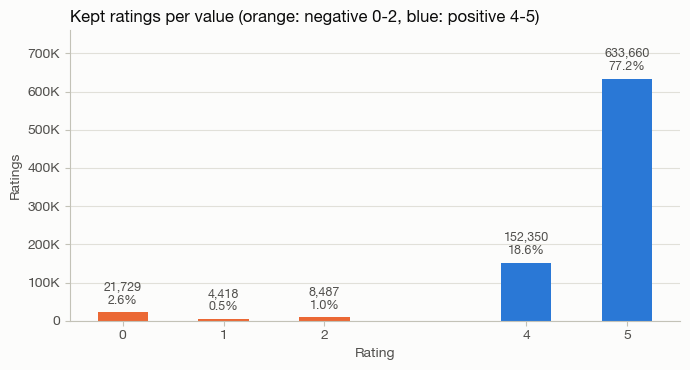

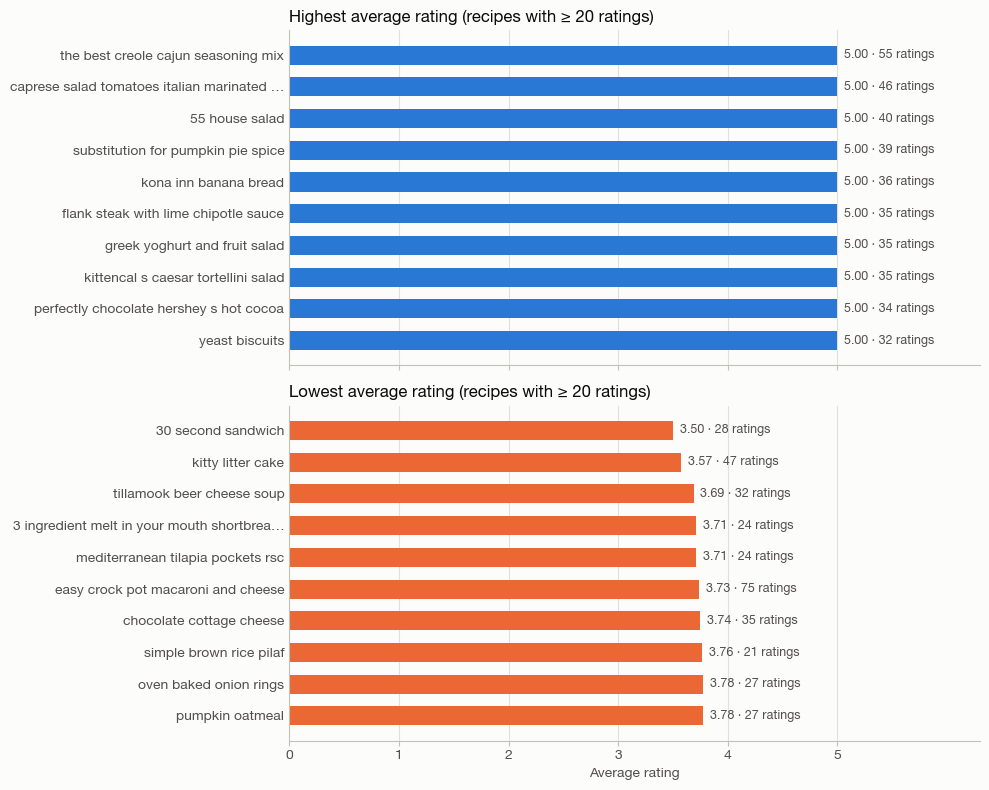

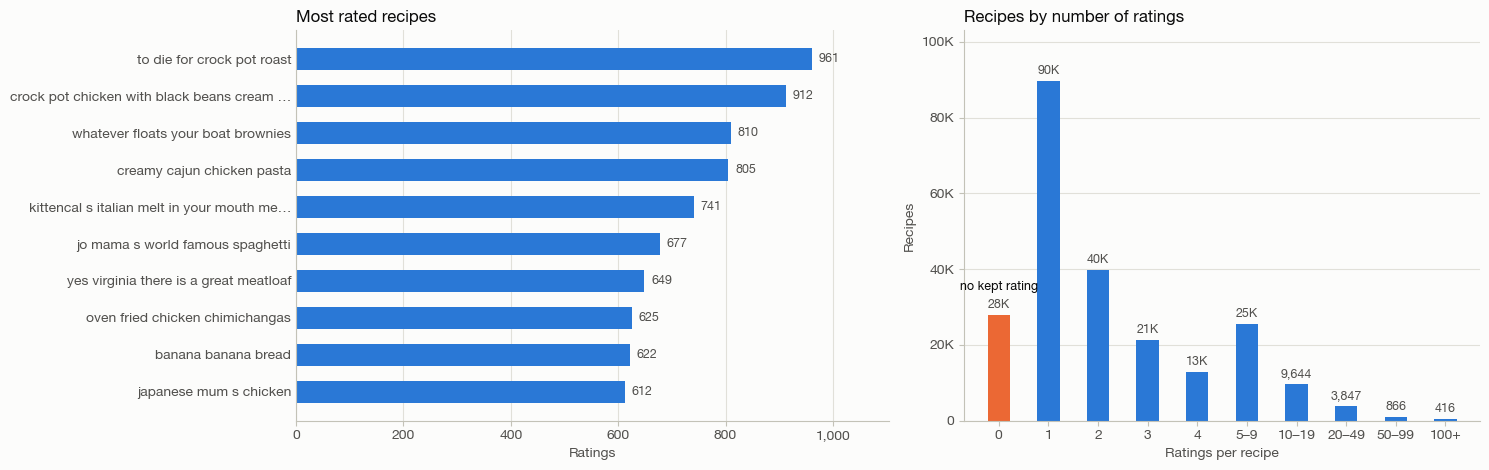

27,884 of 231,637 recipes (12.0%) have no kept rating; 89,612 have exactly one.


,recipe_id,name,rating_count,average_rating
least rated,,,,
0,146767,1 2 3 biscuits,0,NaN
1,206648,1 2 3 hot chocolate,0,NaN
2,377326,1 2 3 peanut butter cookies,0,NaN
3,471666,1 2 3 swiss meringue buttercream,0,NaN
4,12983,1 2 hour raisin pudding,0,NaN
5,385464,1 5 quart crock pot rice pudding,0,NaN
6,267159,1 dish hot fudge swirl cake,0,NaN
7,190411,1 dish pizza bake,0,NaN
8,144952,1 french onion soup,0,NaN


In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

MIN_RATINGS_FOR_AVERAGE = 20
TOP_N = 10
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
VIZ_STYLE = {
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.titlelocation": "left", "axes.titlecolor": INK,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
}


def compact(value, _=None):
    return f"{value / 1e6:.1f}M" if value >= 1e6 else f"{value / 1e3:.0f}K" if value >= 1e4 else f"{value:,.0f}"


def short_name(name, width=42):
    name = " ".join(str(name).split())
    return name if len(name) <= width else name[:width - 1] + "…"


def ranked_bars(ax, frame, value, color, label, title):
    """Horizontal bars, first row on top, each labeled at its tip."""
    rows = frame.iloc[::-1]
    ax.barh(range(len(rows)), rows[value], height=0.6, color=color)
    ax.set_yticks(range(len(rows)), [short_name(name) for name in rows["name"]])
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", visible=False)
    for y, (_, row) in enumerate(rows.iterrows()):
        ax.annotate(label(row), (row[value], y), xytext=(5, 0), textcoords="offset points",
                    va="center", color=INK_2, fontsize=9)
    ax.set_title(title)


rating_values = pd.Index(SENTIMENT_RATINGS, name="rating")
recipe_stats = item_catalog[["recipe_id", "name"]].copy()
recipe_stats["name"] = recipe_stats["name"].map(lambda name: " ".join(str(name).split()))
per_recipe = observed_kept.groupby("item_index")["rating"].agg(["size", "mean"]).reindex(range(len(item_catalog)))
recipe_stats["rating_count"] = per_recipe["size"].fillna(0).astype(np.int64).to_numpy()
recipe_stats["average_rating"] = per_recipe["mean"].to_numpy()

# 1. Ratings per value, coloured by sentiment.
class_counts = observed_kept["rating"].astype(int).value_counts().reindex(rating_values, fill_value=0)
with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(7, 3.8))
    ax.bar(class_counts.index, class_counts, width=0.5,
           color=[BLUE if rating >= SENTIMENT_POSITIVE_MIN else ORANGE for rating in class_counts.index])
    for rating, count in class_counts.items():
        ax.annotate(f"{count:,}\n{count / class_counts.sum():.1%}", (rating, count), xytext=(0, 4),
                    textcoords="offset points", ha="center", va="bottom", color=INK_2, fontsize=9)
    ax.set(xticks=class_counts.index, xlabel="Rating", ylabel="Ratings",
           title="Kept ratings per value (orange: negative 0-2, blue: positive 4-5)")
    ax.yaxis.set_major_formatter(FuncFormatter(compact))
    ax.grid(axis="x", visible=False)
    ax.margins(y=0.2)
    fig.tight_layout()
    plt.show()

# 2. Highest and lowest average rating among recipes with enough ratings.
rated_enough = recipe_stats[recipe_stats["rating_count"] >= MIN_RATINGS_FOR_AVERAGE]
best_rated = rated_enough.sort_values(["average_rating", "rating_count"], ascending=[False, False]).head(TOP_N)
worst_rated = rated_enough.sort_values(["average_rating", "rating_count"], ascending=[True, False]).head(TOP_N)
average_label = lambda row: f"{row.average_rating:.2f} · {row.rating_count:,} ratings"
with plt.rc_context(VIZ_STYLE):
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    ranked_bars(axes[0], best_rated, "average_rating", BLUE, average_label,
                f"Highest average rating (recipes with ≥ {MIN_RATINGS_FOR_AVERAGE} ratings)")
    ranked_bars(axes[1], worst_rated, "average_rating", ORANGE, average_label,
                f"Lowest average rating (recipes with ≥ {MIN_RATINGS_FOR_AVERAGE} ratings)")
    axes[1].set(xlim=(0, 6.3), xticks=range(6), xlabel="Average rating")
    fig.tight_layout()
    plt.show()

# 3. Most rated recipes, and recipes by number of ratings (0 = without a rating).
most_rated = recipe_stats.nlargest(TOP_N, "rating_count")
bucket_labels = ["0", "1", "2", "3", "4", "5–9", "10–19", "20–49", "50–99", "100+"]
buckets = pd.cut(recipe_stats["rating_count"], [0, 1, 2, 3, 4, 5, 10, 20, 50, 100, np.inf],
                 right=False, labels=bucket_labels).value_counts().reindex(bucket_labels)
with plt.rc_context(VIZ_STYLE):
    fig, (left, right) = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.15, 1]})
    ranked_bars(left, most_rated, "rating_count", BLUE, lambda row: f"{row.rating_count:,}", "Most rated recipes")
    left.set(xlim=(0, most_rated["rating_count"].max() * 1.15), xlabel="Ratings")
    left.xaxis.set_major_formatter(FuncFormatter(compact))
    right.bar(bucket_labels, buckets, width=0.45, color=[ORANGE] + [BLUE] * (len(bucket_labels) - 1))
    for x, count in enumerate(buckets):
        right.annotate(compact(count), (x, count), xytext=(0, 3), textcoords="offset points",
                       ha="center", va="bottom", color=INK_2, fontsize=9)
    right.annotate("no kept rating", (0, buckets.iloc[0]), xytext=(0, 16), textcoords="offset points",
                   ha="center", va="bottom", color=INK, fontsize=9)
    right.set(title="Recipes by number of ratings", xlabel="Ratings per recipe", ylabel="Recipes")
    right.yaxis.set_major_formatter(FuncFormatter(compact))
    right.grid(axis="x", visible=False)
    right.margins(y=0.15)
    fig.tight_layout()
    plt.show()

unrated = recipe_stats["rating_count"].eq(0)
print(f"{unrated.sum():,} of {len(recipe_stats):,} recipes ({unrated.mean():.1%}) have no kept rating; "
      f"{recipe_stats['rating_count'].eq(1).sum():,} have exactly one.")
least_rated = recipe_stats.sort_values(["rating_count", "name"], kind="stable").head(TOP_N)
display(least_rated.reset_index(drop=True).rename_axis("least rated"))

**Ratings per user**

How much history each user has: the 0–2★ and 4–5★ ratings of every user (orange: fewer than `MIN_USER_RATINGS`, dropped;
blue: kept), then for the kept users per split, and the labelled rows with the sampled negatives. The user tower learns a
user's taste only from their earlier ratings.


,users,ratings,mean,median,p75,p90,p99,max,share_with_1,share_with_5_or_fewer
every user,221173.0,1091512.0,4.935,1.0,2.0,5.0,60.00,7667.0,0.734,0.914
kept users,19079.0,820644.0,43.013,12.0,27.0,69.0,581.54,7667.0,0.000,0.000
train,19079.0,782486.0,41.013,10.0,25.0,67.0,579.54,7665.0,0.000,0.229
valid,19079.0,19079.0,1.000,1.0,1.0,1.0,1.00,1.0,1.000,1.000
test,19079.0,19079.0,1.000,1.0,1.0,1.0,1.00,1.0,1.000,1.000
labelled rows (with sampled),19079.0,1606654.0,84.211,24.0,52.0,134.0,1144.88,15328.0,0.000,0.000


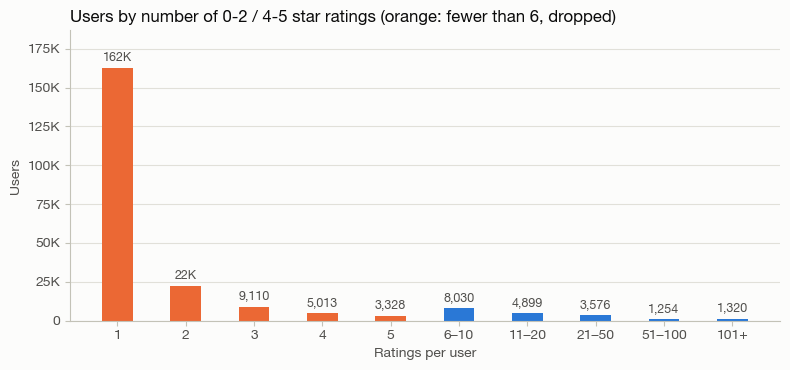

In [8]:
per_user = {name: frame.groupby("user_id").size()
            for name, frame in [("every user", every_rating), ("kept users", observed_kept),
                                ("train", observed_kept[observed_kept["split"] == "train"]),
                                ("valid", observed_kept[observed_kept["split"] == "valid"]),
                                ("test", observed_kept[observed_kept["split"] == "test"]),
                                ("labelled rows (with sampled)", sentiment_rows)]}
user_summary = pd.DataFrame({
    name: {"users": len(counts), "ratings": int(counts.sum()), "mean": counts.mean(), "median": counts.median(),
           "p75": counts.quantile(0.75), "p90": counts.quantile(0.90), "p99": counts.quantile(0.99),
           "max": counts.max(), "share_with_1": (counts == 1).mean(), "share_with_5_or_fewer": (counts <= 5).mean()}
    for name, counts in per_user.items()
}).T
display(user_summary.round(3))

user_bucket_labels = ["1", "2", "3", "4", "5", "6–10", "11–20", "21–50", "51–100", "101+"]
user_buckets = pd.cut(per_user["every user"], [0, 1, 2, 3, 4, 5, 10, 20, 50, 100, np.inf],
                      labels=user_bucket_labels).value_counts().reindex(user_bucket_labels)
with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(8, 3.8))
    ax.bar(user_bucket_labels, user_buckets, width=0.45,
           color=[ORANGE if label in {"1", "2", "3", "4", "5"} else BLUE for label in user_bucket_labels])
    for x, count in enumerate(user_buckets):
        ax.annotate(compact(count), (x, count), xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", color=INK_2, fontsize=9)
    ax.set(title=f"Users by number of 0-2 / 4-5 star ratings (orange: fewer than {MIN_USER_RATINGS}, dropped)",
           xlabel="Ratings per user", ylabel="Users")
    ax.yaxis.set_major_formatter(FuncFormatter(compact))
    ax.grid(axis="x", visible=False)
    ax.margins(y=0.15)
    fig.tight_layout()
    plt.show()


**Recipe prices and nutrient values**

One value per recipe in `item_catalog`, rated or not, before the item tower's `log1p`, clipping,
and scaling:

- **Nutrients:** the seven nutrition columns as they come from the input CSV. Every column is
  right-skewed, so the x-axes are logarithmic. A log axis can't show zeros, so each title gives
  their share, and the line marks the median. The CSV's values are Food.com's nutrition values
  times each nutrient's daily value (calories × 2000, sugar × 50, …), so compare shapes rather
  than magnitudes.
- **Prices:** the known ingredient prices summed per recipe, and how many of its ingredients
  have no price. Each missing price adds ±$2 of uncertainty (`MISSING_PRICE_ERROR_DOLLARS`),
  not an imputed cost.

The table gives each column's share of missing and zero values and its 1st, 50th, and 99th
percentiles.

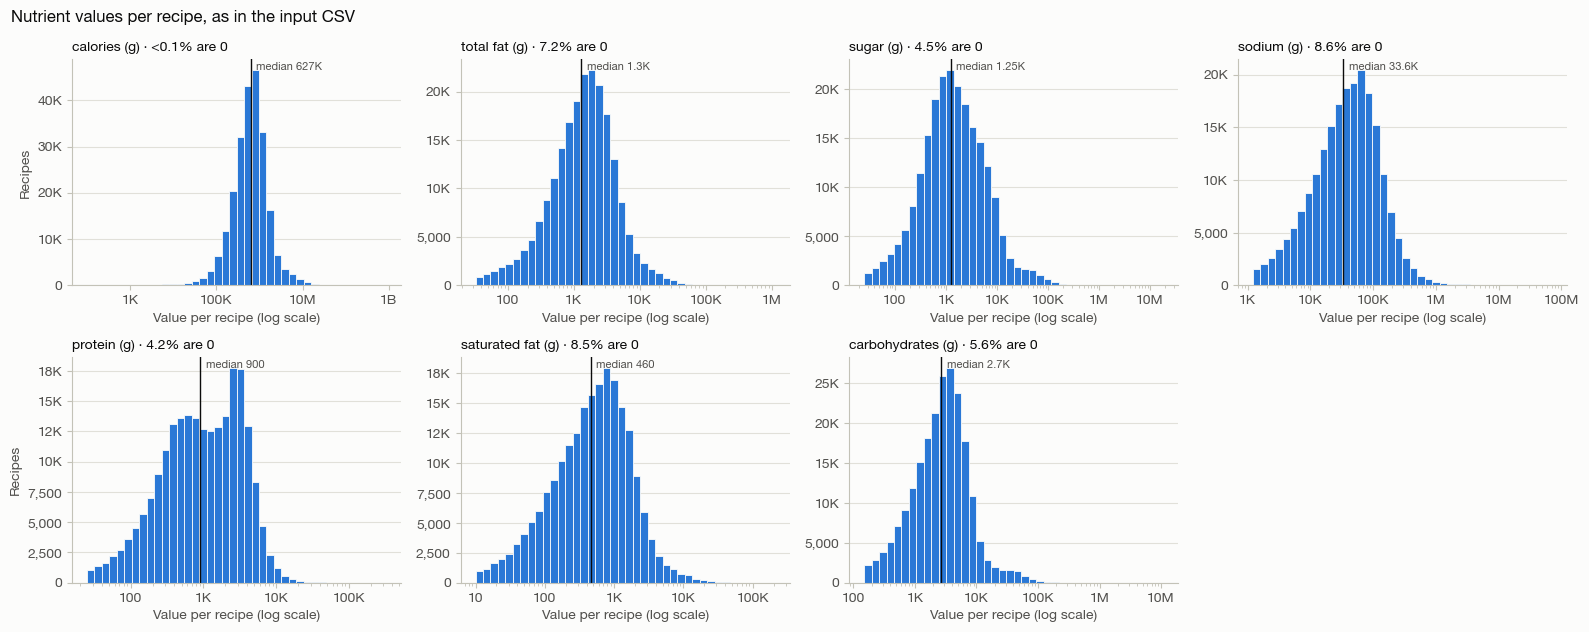

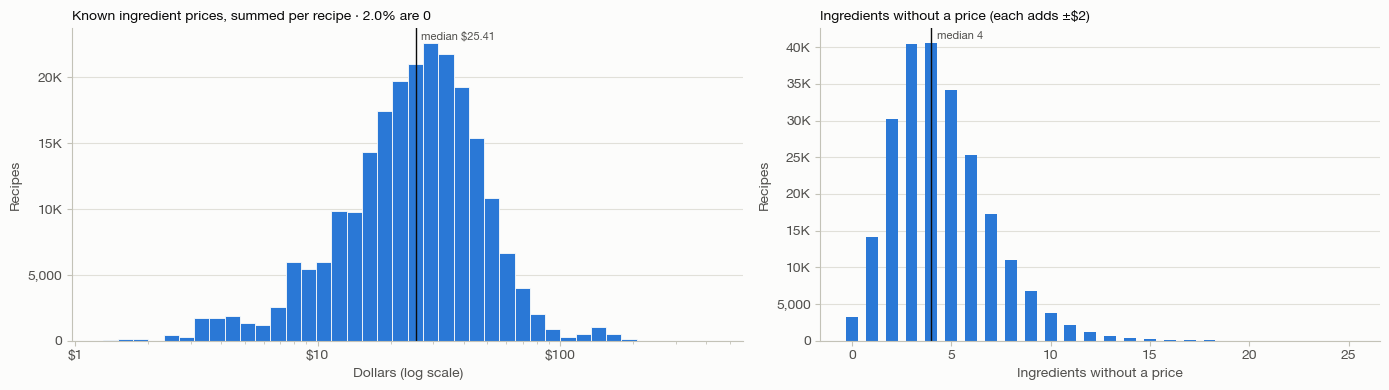

,count,missing_share,zero_share,min,1%,50%,99%,max
calories (g),231637.0,0.0,0.000,0.0,36800.0,626800.00,7033912.000,8.687204e+08
total fat (g),231637.0,0.0,0.072,0.0,0.0,1300.00,19630.000,1.116895e+06
sugar (g),231637.0,0.0,0.045,0.0,0.0,1250.00,57082.000,1.813645e+07
sodium (g),231637.0,0.0,0.086,0.0,0.0,33600.00,525600.000,7.041120e+07
protein (g),231637.0,0.0,0.042,0.0,0.0,900.00,9400.000,3.276000e+05
saturated fat (g),231637.0,0.0,0.085,0.0,0.0,460.00,8080.000,2.079000e+05
carbohydrates (g),231637.0,0.0,0.056,0.0,0.0,2700.00,46200.000,1.082940e+07
price_total_known,231637.0,0.0,0.020,0.0,0.0,25.41,104.968,4.259900e+02
price_missing_count,231637.0,0.0,0.014,0.0,0.0,4.00,12.000,2.500000e+01
price_lower,231637.0,0.0,0.102,0.0,0.0,16.66,94.315,4.119900e+02


In [9]:
DISTRIBUTION_BINS = 40


def short_number(value, _=None):
    """1.2K, 3.4M, 5.6B, or the value itself, to 3 significant digits."""
    for limit, suffix in ((1e9, "B"), (1e6, "M"), (1e3, "K")):
        if abs(value) >= limit:
            return f"{value / limit:.3g}{suffix}"
    return f"{value:.3g}"


def log_histogram(ax, values, title, xlabel, value_format=short_number):
    """Histogram of the positive values on a log x-axis with the median marked; zeros are counted in the title.

    The values come in whole steps (a nutrient in one daily-value percent, a price in cents), so
    each is spread uniformly across its step before binning; narrow log bins would otherwise hold
    one or two steps in turn and show combs that aren't in the data.
    """
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    positive = values[values > 0]
    distinct = np.unique(positive)
    step = np.diff(distinct).min() if len(distinct) > 1 else 0.0
    spread = positive + np.random.default_rng(0).uniform(-step / 2, step / 2, len(positive))
    spread = spread[spread > 0]
    ax.hist(spread, bins=np.geomspace(spread.min(), spread.max(), DISTRIBUTION_BINS + 1),
            color=BLUE, edgecolor=SURFACE, linewidth=0.6)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(FuncFormatter(short_number))
    median = np.median(values)
    if median > 0:
        ax.axvline(median, color=INK, linewidth=1)
        ax.annotate(f"median {value_format(median)}", (median, 1), xycoords=("data", "axes fraction"),
                    xytext=(4, -2), textcoords="offset points", va="top", color=INK_2, fontsize=8)
    zeros = np.mean(values == 0)
    zero_text = "" if not zeros else f" · {zeros:.1%} are 0" if zeros >= 0.001 else " · <0.1% are 0"
    ax.set_title(title + zero_text, fontsize=10)
    ax.set(xlabel=xlabel, ylabel="Recipes")
    ax.yaxis.set_major_formatter(FuncFormatter(compact))
    ax.grid(axis="x", visible=False)


distribution_columns = [*NUTRITION_COLUMNS, "price_total_known", "price_missing_count", "price_lower", "price_upper"]
distribution_values = item_catalog[distribution_columns].apply(pd.to_numeric, errors="coerce")

# 1. Nutrients: one panel per column.
with plt.rc_context(VIZ_STYLE):
    fig, axes = plt.subplots(2, 4, figsize=(16, 6.4))
    for ax, column in zip(axes.flat, NUTRITION_COLUMNS):
        log_histogram(ax, distribution_values[column], column, "Value per recipe (log scale)")
    for ax in axes[:, 1:].flat:
        ax.set_ylabel("")
    axes.flat[-1].axis("off")
    fig.suptitle("Nutrient values per recipe, as in the input CSV", x=0.01, ha="left",
                 fontsize=12, fontweight="semibold")
    fig.tight_layout()
    plt.show()

# 2. Prices: the summed known prices, and how many ingredients have no price.
missing_prices = distribution_values["price_missing_count"].astype(int).value_counts().sort_index()
with plt.rc_context(VIZ_STYLE):
    fig, (left, right) = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [1.2, 1]})
    log_histogram(left, distribution_values["price_total_known"], "Known ingredient prices, summed per recipe",
                  "Dollars (log scale)", value_format=lambda value: f"${value:,.2f}")
    left.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value:,.0f}" if value >= 1 else f"${value:.2g}"))
    right.bar(missing_prices.index, missing_prices, width=0.6, color=BLUE)
    median_missing = distribution_values["price_missing_count"].median()
    right.axvline(median_missing, color=INK, linewidth=1)
    right.annotate(f"median {median_missing:g}", (median_missing, 1), xycoords=("data", "axes fraction"),
                   xytext=(4, -2), textcoords="offset points", va="top", color=INK_2, fontsize=8)
    right.set_title(f"Ingredients without a price (each adds ±${MISSING_PRICE_ERROR_DOLLARS:g})", fontsize=10)
    right.set(xlabel="Ingredients without a price", ylabel="Recipes")
    right.yaxis.set_major_formatter(FuncFormatter(compact))
    right.grid(axis="x", visible=False)
    fig.tight_layout()
    plt.show()

distribution_summary = distribution_values.describe(percentiles=[0.01, 0.5, 0.99]).T.drop(columns=["mean", "std"])
distribution_summary.insert(1, "missing_share", distribution_values.isna().mean())
distribution_summary.insert(2, "zero_share", distribution_values.eq(0).mean())
display(distribution_summary.round(3))

**Tokens: the `model_training_mf_als.ipynb` cleaning**

The product (or raw ingredient), adjective and verb terms of every recipe are cleaned again with the rules above; the tags keep
the catalog's processing. The table compares the distinct terms per field before (`build_recipe_catalog`'s
`normalize_terms`) and after, and lists recipes whose terms changed.


In [10]:
sentiment_text_column = "product" if "product" in item_catalog else "ingredients"
sentiment_catalog_terms = {
    "ingredients": [clean_token_list(flatten_terms(entities) or flatten_terms(original), TOKEN_POS_BY_FIELD["ingredients"])
                    for entities, original in zip(item_catalog[sentiment_text_column], item_catalog["ingredients"])],
    "adjectives": [clean_token_list(flatten_terms(value), TOKEN_POS_BY_FIELD["adjectives"]) for value in item_catalog["adj"]],
    "verbs": [clean_token_list(flatten_terms(value), TOKEN_POS_BY_FIELD["verbs"]) for value in item_catalog["verb"]],
    "tags": item_catalog["tag_terms"].tolist(),
}
retrieval_terms = {"ingredients": item_catalog["ingredient_terms"], "adjectives": item_catalog["adj_terms"],
                   "verbs": item_catalog["verb_terms"]}
display(pd.DataFrame({field: {
    "distinct terms before": len({term for terms in retrieval_terms[field] for term in terms}),
    "distinct terms after": len({term for terms in sentiment_catalog_terms[field] for term in terms}),
    "recipes whose terms changed": int(sum(list(old) != new for old, new in zip(retrieval_terms[field], sentiment_catalog_terms[field]))),
} for field in retrieval_terms}).T)
changed_recipes = [position for position, (old, new) in enumerate(zip(item_catalog["ingredient_terms"], sentiment_catalog_terms["ingredients"]))
                   if list(old) != new][:8]
display(pd.DataFrame({"recipe": item_catalog["name"].to_numpy()[changed_recipes],
                      "ingredients before": item_catalog["ingredient_terms"].to_numpy()[changed_recipes],
                      "ingredients after": [sentiment_catalog_terms["ingredients"][position] for position in changed_recipes]}))


,distinct terms before,distinct terms after,recipes whose terms changed
ingredients,8601,8602,7455
adjectives,837,788,3393
verbs,403,371,2527


,recipe,ingredients before,ingredients after
0,boat house collard greens,"[collard green, brown sugar, molasses, sauce, ...","[collard greens, brown sugar, molasses, sauce,..."
1,cream of spinach soup vegan,"[onion, scallion, apple juice, olive oil, spin...","[onion, scallion, apple juice, olive oil, spin..."
2,berry french toast oatmeal,"[old fashioned oat, berry, flax seed, sugar fr...","[old fashioned oats, berry, flax seed, sugar f..."
3,dressed up salad with secret dressing,"[salad green, onion, salt, pepper, salad seaso...","[salad greens, onion, salt, pepper, salad seas..."
4,egg cellent noodles,"[ramen noodle, egg, bell pepper, olive, pepper...","[ramen noodle, egg, bell pepper, olive, pepper..."
5,flaky oatmeal raisin cookies,"[brown sugar, butter, egg, baking soda, baking...","[brown sugar, butter, egg, baking soda, baking..."
6,ma s oatmeal cake and icing,"[boiling water, quick oat, margarine, brown su...","[boiling water, quick oats, margarine, brown s..."
7,baked apple cinnamon oatmeal,"[apple, brown sugar, oat, cranberry, margarine...","[apple, brown sugar, oats, cranberry, margarin..."


**Recipe features: standardized, embeddings and nutrients reduced by UMAP**

UMAP is fit on **every catalog recipe** (text, nutrients) and every term (terms): it uses no labels, and fitting on all of
them means no recipe needs UMAP's `transform` (whose result depends on which rows are transformed together). The first run
takes a while: BERT embeds every recipe's text (about 20 minutes on Apple silicon, a few on a CUDA GPU) and the text UMAP on
~230k × 768 values is the longest UMAP (`UMAP_SEED = None` uses every core). Both are cached in `output/two_tower_cache`, so
later runs read them back. Price and time are standardized on the train recipes.


In [11]:
sentiment_train_items = np.unique(sentiment_rows.loc[sentiment_rows["split"] == "train", "item_index"].to_numpy())
sentiment_train_mask = _train_mask(len(item_catalog), sentiment_train_items)

# Nutrients: missing -> median, log1p, clip at CLIP_QUANTILE, then standardize -> UMAP -> standardize.
nutrient_raw = item_catalog[NUTRITION_COLUMNS].to_numpy(dtype=np.float64)
nutrient_missing = ~np.isfinite(nutrient_raw)
nutrient_medians = pd.DataFrame(np.where(nutrient_missing, np.nan, nutrient_raw)).median().fillna(0).to_numpy()
nutrient_logged = np.log1p(np.clip(np.where(nutrient_missing, nutrient_medians, nutrient_raw), 0, None))
nutrient_clip_limits = np.quantile(nutrient_logged, CLIP_QUANTILE, axis=0)
nutrient_components, nutrient_scaler, nutrient_umap_scaler = standardize_then_umap(
    np.minimum(nutrient_logged, nutrient_clip_limits), NUTRIENT_UMAP_COMPONENTS, "nutrients")
# Price and time: log1p, clip, standardize (on the train recipes).
price_standardized, price_clip_limits, price_scaler = _log_clip_scale(
    item_catalog[PRICE_FEATURE_COLUMNS].to_numpy(dtype=np.float64), sentiment_train_mask, CLIP_QUANTILE, [0, 1])
time_standardized, time_preprocessing = build_recipe_extras(recipe_metadata, sentiment_train_items, clip_quantile=CLIP_QUANTILE)
# Text: the full BERT embedding (cached after the first run) -> standardize -> UMAP -> standardize.
bert_vectors, _ = encode_recipe_texts(recipe_texts(item_catalog, recipe_metadata), CACHE_DIR, device, model_name=BERT_MODEL,
                                      revision=BERT_REVISION, batch_size=TEXT_BATCH_SIZE, max_length=TEXT_MAX_LENGTH,
                                      dim=10_000, seed=RANDOM_STATE)  # dim above BERT's width: no SVD
text_components, text_scaler, text_umap_scaler = standardize_then_umap(bert_vectors, TEXT_UMAP_COMPONENTS, "text")
# Terms: one frozen MiniLM vector per cleaned term -> standardize -> UMAP -> standardize.
sentiment_term_vocabulary = sorted({term for terms in sentiment_catalog_terms.values() for recipe_terms in terms
                                    for term in recipe_terms})
term_vectors_full = encode_terms(sentiment_term_vocabulary, CACHE_DIR, device, model_name=TERM_MODEL, revision=TERM_REVISION,
                                 batch_size=TERM_BATCH_SIZE)
sentiment_term_vectors, term_scaler, term_umap_scaler = standardize_then_umap(term_vectors_full, TERM_UMAP_COMPONENTS, "terms")
sentiment_item_terms = {field: term_id_matrix(terms, sentiment_term_vocabulary) for field, terms in sentiment_catalog_terms.items()}

sentiment_item_features, sentiment_feature_groups = stack_feature_groups(
    {"nutrition": nutrient_components, "price": price_standardized, "time": time_standardized, "text": text_components})
assert np.isfinite(sentiment_item_features).all() and np.isfinite(sentiment_term_vectors).all()
sentiment_content_preprocessing = {
    "nutrition": {"columns": NUTRITION_COLUMNS, "medians": nutrient_medians, "clip_limits": nutrient_clip_limits,
                  "scaler": nutrient_scaler, "umap_output_scaler": nutrient_umap_scaler},
    "price": {"columns": PRICE_FEATURE_COLUMNS, "clip_limits": price_clip_limits, "scaler": price_scaler},
    "time": time_preprocessing,
    "text": {"model": BERT_MODEL, "revision": BERT_REVISION, "scaler": text_scaler, "umap_output_scaler": text_umap_scaler},
    "terms": {"vocabulary": sentiment_term_vocabulary, "model": TERM_MODEL, "revision": TERM_REVISION, "scaler": term_scaler,
              "umap_output_scaler": term_umap_scaler, "catalog_terms": sentiment_catalog_terms},
    "umap": {"n_neighbors": UMAP_NEIGHBORS, "min_dist": UMAP_MIN_DIST, "random_state": UMAP_SEED},
    "feature_groups": sentiment_feature_groups, "clip_quantile": CLIP_QUANTILE,
}
display(pd.DataFrame({"input dimensions": {"nutrients": len(NUTRITION_COLUMNS), "text (BERT)": bert_vectors.shape[1],
                                           "terms (MiniLM)": term_vectors_full.shape[1]},
                      "UMAP components": {"nutrients": NUTRIENT_UMAP_COMPONENTS, "text (BERT)": TEXT_UMAP_COMPONENTS,
                                          "terms (MiniLM)": TERM_UMAP_COMPONENTS}}))
print(f"Item features: {sentiment_item_features.shape}; groups: "
      + ", ".join(f"{name} {end - start}" for name, start, end in sentiment_feature_groups)
      + f"; {len(sentiment_term_vocabulary):,} terms x {sentiment_term_vectors.shape[1]} (UMAP) dimensions")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


UMAP nutrients: (231637, 7) -> 6 dimensions in 147s (cached)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP text: (231637, 768) -> 32 dimensions in 359s (cached)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP terms: (9795, 384) -> 32 dimensions in 14s (cached)


,input dimensions,UMAP components
nutrients,7,6
text (BERT),768,32
terms (MiniLM),384,32


Item features: (231637, 46); groups: nutrition 6, price 4, time 4, text 32; 9,795 terms x 32 (UMAP) dimensions


**Training and evaluation**

Every epoch prints the train focal loss, the valid focal loss (same class weights), the valid weighted log loss that picks the
epoch, and the valid ROC AUC and macro F1. Then: the valid and test scores (per sentiment: precision, recall, F1; ROC AUC,
average precision, losses), the test confusion matrix, and how each kind of test row is predicted (4–5★ ratings, real 0–2★
ratings, sampled unobserved recipes). The weights are saved and reloaded as a check.


In [ ]:
sentiment_result = run_sentiment_two_tower()
show_sentiment_results(sentiment_result)


1,533,853 train rows (751,367 positive, 782,486 negative), class weights negative 0.980 / positive 1.021; 37,195 recipes get an ID embedding
epoch 01: train focal loss 0.1608, valid focal loss 0.1452, valid weighted log loss 0.6182, valid ROC AUC 0.7758, macro F1 0.7211 (184s)
epoch 02: train focal loss 0.1489, valid focal loss 0.1433, valid weighted log loss 0.6042, valid ROC AUC 0.7820, macro F1 0.7222 (199s)


**Recommend unseen recipes**

For a user, the user tower reads every observed rating of theirs (all splits, with its sentiment), and every recipe that appears
in the data is scored by P(positive); recipes they already rated are never recommended. The example is the user with the most
kept ratings.


In [ ]:
candidate_recipes = np.sort(sentiment_rows["item_index"].unique())
example_user_id = observed_kept["user_id"].value_counts().index[0]
print(f"Top recipes for user {example_user_id} ({int((observed_kept['user_id'] == example_user_id).sum())} kept ratings), "
      f"out of {len(candidate_recipes):,} recipes")
display(recommend_by_sentiment(sentiment_result["model"], example_user_id, observed_kept, candidate_recipes, top_k=20))
